In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abozeidmohamed/dataset/label_encoder_classes (1).npy
/kaggle/input/datasets/abozeidmohamed/dataset/encoded_labels_under (2).npy
/kaggle/input/datasets/abozeidmohamed/dataset/images_under (1).npy


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split

# ── تحميل الداتا ─────────────────────────────────────────────
x = np.load('/kaggle/input/datasets/abozeidmohamed/dataset/images_under (1).npy')
y = np.load('/kaggle/input/datasets/abozeidmohamed/dataset/encoded_labels_under (2).npy')

# ── لو الصور رمادية نضيف قناة ────────────────────────────────
if len(x.shape) == 3:
    x = np.expand_dims(x, axis=-1)

# ── Normalize ─────────────────────────────────────────────────
x = x.astype('float32') / 255.0

# ══════════════════════════════════════════════════════════════
#  التقسيم: 70% train | 15% val | 15% test
#  (أو غيّر النسب زي ما تحب)
# ══════════════════════════════════════════════════════════════

# الخطوة 1: نفصل الـ test أولاً (15%) من الكل
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y,
    test_size=0.15,
    random_state=42,
    stratify=y          # محافظة على نسب الكلاسات
)

# الخطوة 2: نقسم الباقي (85%) لـ train (70%) و val (15%)
# 0.15 / 0.85 ≈ 0.176 عشان الـ val تبقى 15% من الكل
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

# ── معلومات التقسيم ───────────────────────────────────────────
input_shape = x.shape[1:]
num_classes = len(np.unique(y))

print("=" * 45)
print(f"  Total samples   : {len(x)}")
print(f"  Train samples   : {len(x_train)}  ({len(x_train)/len(x)*100:.1f}%)")
print(f"  Val   samples   : {len(x_val)}   ({len(x_val)/len(x)*100:.1f}%)")
print(f"  Test  samples   : {len(x_test)}   ({len(x_test)/len(x)*100:.1f}%)")
print(f"  Input shape     : {input_shape}")
print(f"  Num classes     : {num_classes}")
print("=" * 45)

  Total samples   : 32128
  Train samples   : 22501  (70.0%)
  Val   samples   : 4807   (15.0%)
  Test  samples   : 4820   (15.0%)
  Input shape     : (64, 64, 1)
  Num classes     : 32


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_cnn():
    model = Sequential([

        # --- Block 1 ---
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 2 ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 3 ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 4 ---
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 5 ---
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Dense Layers ---
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


2026-05-21 08:17:39.643403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779351459.810207      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779351459.859112      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779351460.254068      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779351460.254103      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779351460.254105      57 computation_placer.cc:177] computation placer alr

🔢 Calculating FLOPs & MACs...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779351480.270315      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


  MACs  : 0.0000 M
  FLOPs : 0.0000 M

────────────────────────────────────────
  Run 1/10
────────────────────────────────────────
Epoch 1/20


I0000 00:00:1779351488.887913     129 service.cc:152] XLA service 0x7eba3c0031d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779351488.887944     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779351490.038608     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779351497.780086     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


352/352 - 32s - 91ms/step - accuracy: 0.5575 - loss: 1.5842 - val_accuracy: 0.0312 - val_loss: 5.7979
Epoch 2/20
352/352 - 8s - 22ms/step - accuracy: 0.9233 - loss: 0.2594 - val_accuracy: 0.2498 - val_loss: 2.7713
Epoch 3/20
352/352 - 8s - 22ms/step - accuracy: 0.9705 - loss: 0.1025 - val_accuracy: 0.9536 - val_loss: 0.1784
Epoch 4/20
352/352 - 8s - 21ms/step - accuracy: 0.9838 - loss: 0.0620 - val_accuracy: 0.9800 - val_loss: 0.0668
Epoch 5/20
352/352 - 8s - 22ms/step - accuracy: 0.9892 - loss: 0.0405 - val_accuracy: 0.9852 - val_loss: 0.0583
Epoch 6/20
352/352 - 8s - 22ms/step - accuracy: 0.9881 - loss: 0.0422 - val_accuracy: 0.9852 - val_loss: 0.0605
Epoch 7/20
352/352 - 8s - 21ms/step - accuracy: 0.9848 - loss: 0.0516 - val_accuracy: 0.9875 - val_loss: 0.0523
Epoch 8/20
352/352 - 8s - 21ms/step - accuracy: 0.9871 - loss: 0.0419 - val_accuracy: 0.9863 - val_loss: 0.0529
Epoch 9/20
352/352 - 8s - 21ms/step - accuracy: 0.9884 - loss: 0.0383 - val_accuracy: 0.9472 - val_loss: 0.1773
Ep

  💾 Test probs saved → /kaggle/working/test_probs_run1.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run1.h5


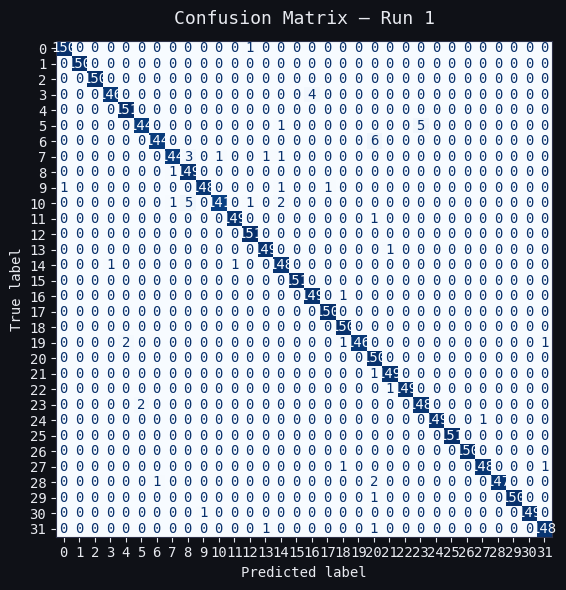

  ✅ saved → /kaggle/working/confusion_matrix_run1.png


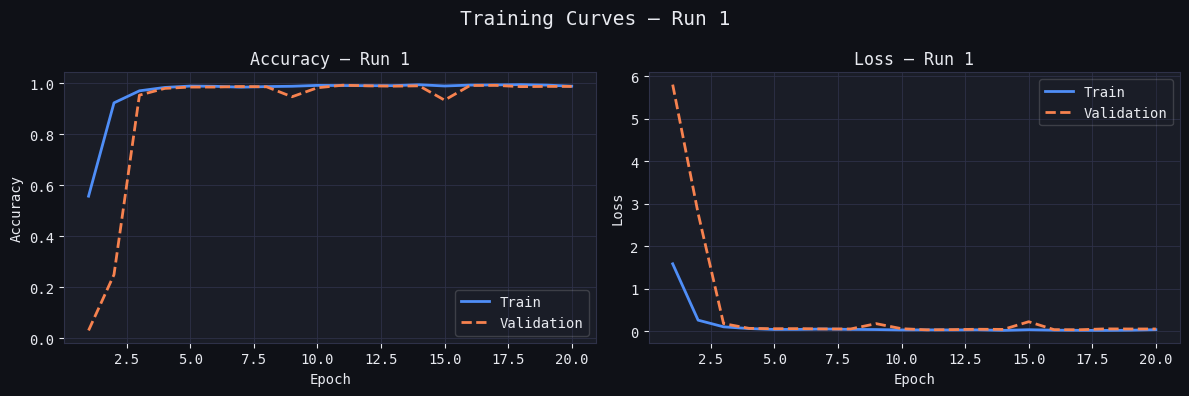

  ✅ saved → /kaggle/working/training_curves_run1.png


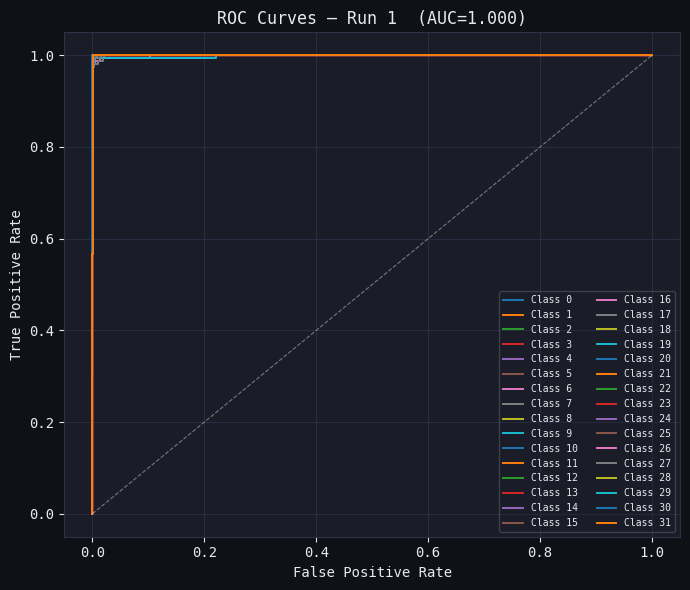

  ✅ saved → /kaggle/working/roc_run1.png


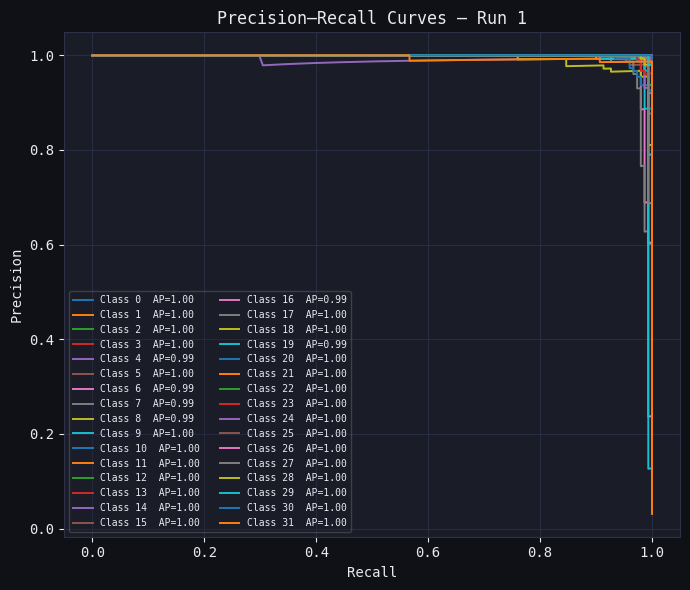

  ✅ saved → /kaggle/working/pr_run1.png

────────────────────────────────────────
  Run 2/10
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
352/352 - 27s - 77ms/step - accuracy: 0.5474 - loss: 1.5994 - val_accuracy: 0.0312 - val_loss: 6.3022
Epoch 2/20
352/352 - 8s - 23ms/step - accuracy: 0.9228 - loss: 0.2596 - val_accuracy: 0.3809 - val_loss: 2.2116
Epoch 3/20
352/352 - 8s - 23ms/step - accuracy: 0.9708 - loss: 0.1028 - val_accuracy: 0.9767 - val_loss: 0.0805
Epoch 4/20
352/352 - 8s - 23ms/step - accuracy: 0.9836 - loss: 0.0605 - val_accuracy: 0.9792 - val_loss: 0.0636
Epoch 5/20
352/352 - 8s - 22ms/step - accuracy: 0.9874 - loss: 0.0478 - val_accuracy: 0.9877 - val_loss: 0.0436
Epoch 6/20
352/352 - 8s - 22ms/step - accuracy: 0.9896 - loss: 0.0399 - val_accuracy: 0.9913 - val_loss: 0.0348
Epoch 7/20
352/352 - 8s - 22ms/step - accuracy: 0.9903 - loss: 0.0348 - val_accuracy: 0.9861 - val_loss: 0.0556
Epoch 8/20
352/352 - 8s - 22ms/step - accuracy: 0.9846 - loss: 0.0509 - val_accuracy: 0.9865 - val_loss: 0.0473
Epoch 9/20
352/352 - 8s - 22ms/step - accuracy: 0.9913 - loss: 0.0326 - val_accuracy: 0.9877 - val_loss

  💾 Test probs saved → /kaggle/working/test_probs_run2.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run2.h5


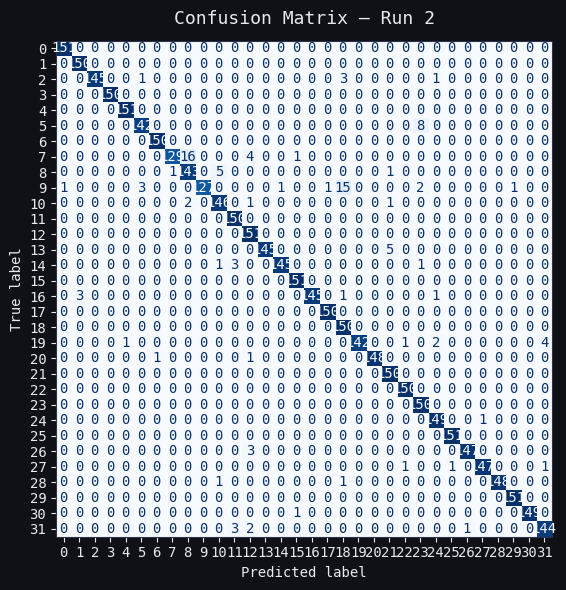

  ✅ saved → /kaggle/working/confusion_matrix_run2.png


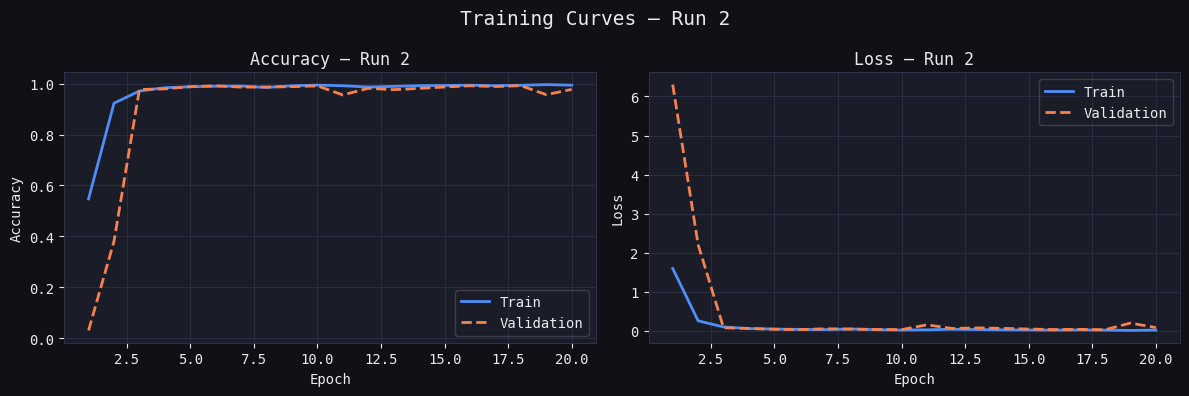

  ✅ saved → /kaggle/working/training_curves_run2.png


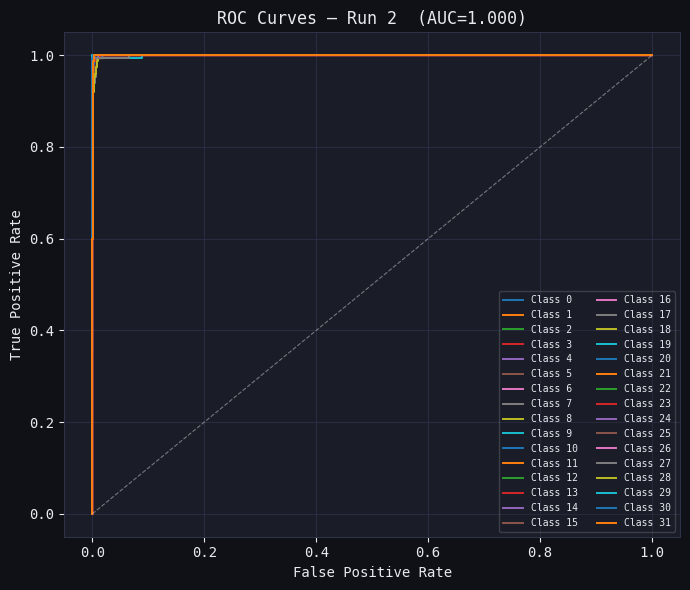

  ✅ saved → /kaggle/working/roc_run2.png


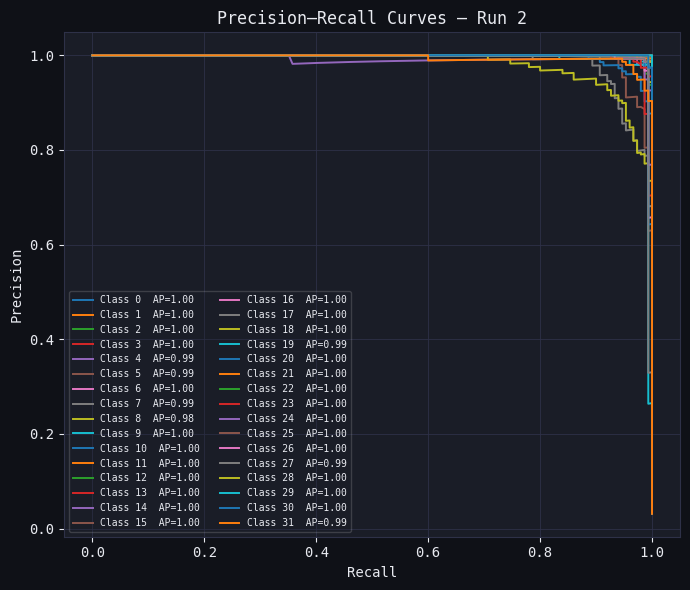

  ✅ saved → /kaggle/working/pr_run2.png

────────────────────────────────────────
  Run 3/10
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
352/352 - 28s - 80ms/step - accuracy: 0.5263 - loss: 1.6624 - val_accuracy: 0.0312 - val_loss: 5.1915
Epoch 2/20
352/352 - 8s - 24ms/step - accuracy: 0.9140 - loss: 0.2826 - val_accuracy: 0.2629 - val_loss: 2.7946
Epoch 3/20
352/352 - 8s - 23ms/step - accuracy: 0.9712 - loss: 0.1023 - val_accuracy: 0.9759 - val_loss: 0.0898
Epoch 4/20
352/352 - 8s - 22ms/step - accuracy: 0.9816 - loss: 0.0659 - val_accuracy: 0.9794 - val_loss: 0.0700
Epoch 5/20
352/352 - 8s - 22ms/step - accuracy: 0.9913 - loss: 0.0356 - val_accuracy: 0.9886 - val_loss: 0.0489
Epoch 6/20
352/352 - 8s - 22ms/step - accuracy: 0.9863 - loss: 0.0438 - val_accuracy: 0.9886 - val_loss: 0.0472
Epoch 7/20
352/352 - 8s - 22ms/step - accuracy: 0.9873 - loss: 0.0416 - val_accuracy: 0.9825 - val_loss: 0.0578
Epoch 8/20
352/352 - 8s - 22ms/step - accuracy: 0.9892 - loss: 0.0382 - val_accuracy: 0.9761 - val_loss: 0.0809
Epoch 9/20
352/352 - 8s - 22ms/step - accuracy: 0.9907 - loss: 0.0325 - val_accuracy: 0.9873 - val_loss

  💾 Test probs saved → /kaggle/working/test_probs_run3.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run3.h5


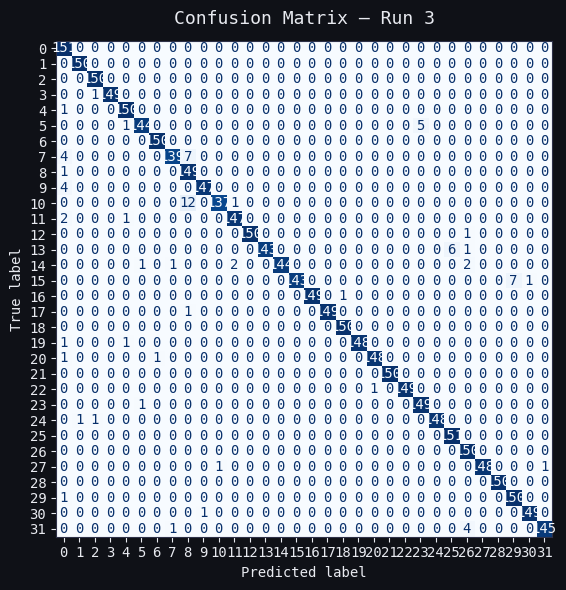

  ✅ saved → /kaggle/working/confusion_matrix_run3.png


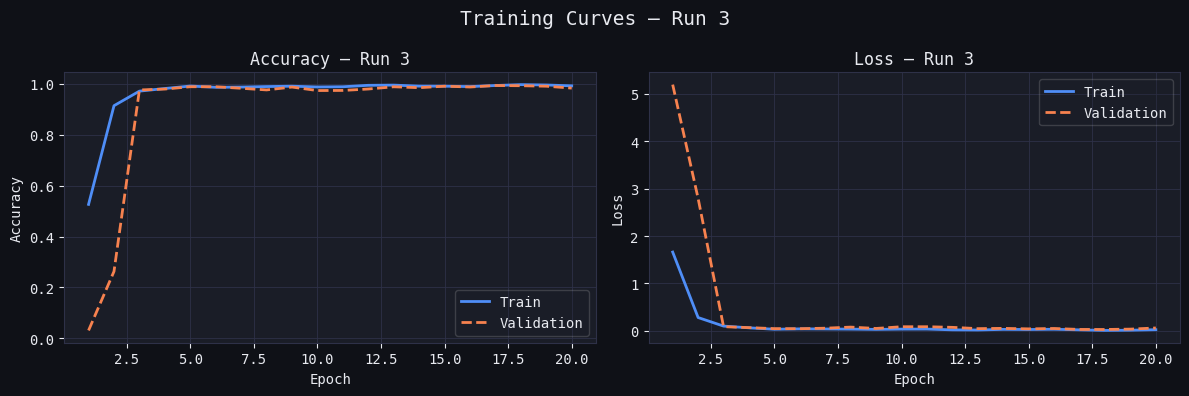

  ✅ saved → /kaggle/working/training_curves_run3.png


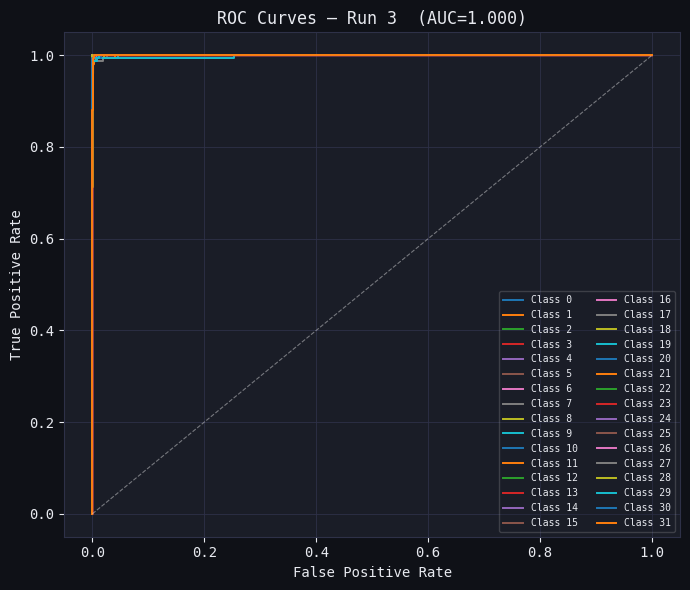

  ✅ saved → /kaggle/working/roc_run3.png


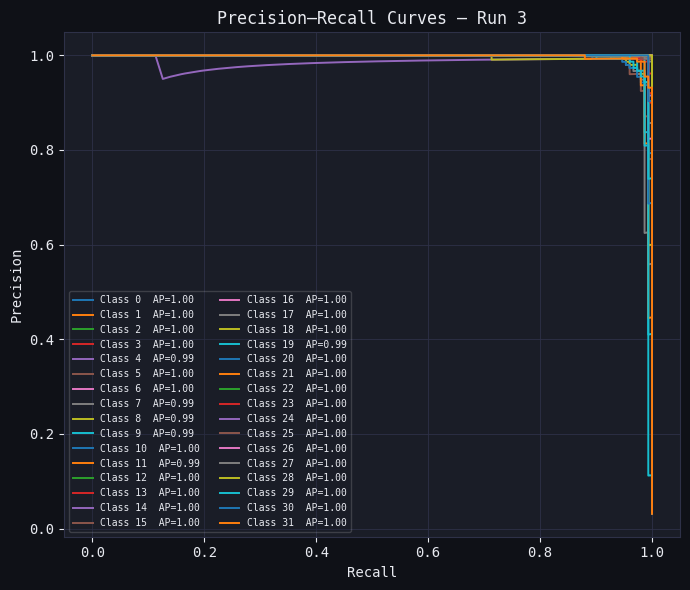

  ✅ saved → /kaggle/working/pr_run3.png

────────────────────────────────────────
  Run 4/10
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
352/352 - 28s - 80ms/step - accuracy: 0.5200 - loss: 1.6993 - val_accuracy: 0.0314 - val_loss: 7.0122
Epoch 2/20
352/352 - 8s - 23ms/step - accuracy: 0.9161 - loss: 0.2872 - val_accuracy: 0.2286 - val_loss: 3.0207
Epoch 3/20
352/352 - 8s - 23ms/step - accuracy: 0.9671 - loss: 0.1171 - val_accuracy: 0.9413 - val_loss: 0.1944
Epoch 4/20
352/352 - 8s - 22ms/step - accuracy: 0.9792 - loss: 0.0731 - val_accuracy: 0.9763 - val_loss: 0.0834
Epoch 5/20
352/352 - 8s - 22ms/step - accuracy: 0.9877 - loss: 0.0463 - val_accuracy: 0.9850 - val_loss: 0.0595
Epoch 6/20
352/352 - 8s - 22ms/step - accuracy: 0.9885 - loss: 0.0385 - val_accuracy: 0.9798 - val_loss: 0.0755
Epoch 7/20
352/352 - 8s - 22ms/step - accuracy: 0.9853 - loss: 0.0476 - val_accuracy: 0.9505 - val_loss: 0.1538
Epoch 8/20
352/352 - 8s - 22ms/step - accuracy: 0.9890 - loss: 0.0392 - val_accuracy: 0.9615 - val_loss: 0.1227
Epoch 9/20
352/352 - 8s - 22ms/step - accuracy: 0.9887 - loss: 0.0377 - val_accuracy: 0.9834 - val_loss

  💾 Test probs saved → /kaggle/working/test_probs_run4.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run4.h5


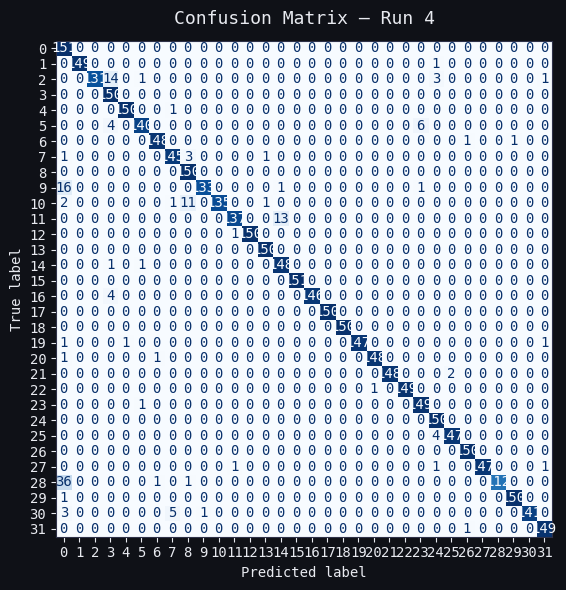

  ✅ saved → /kaggle/working/confusion_matrix_run4.png


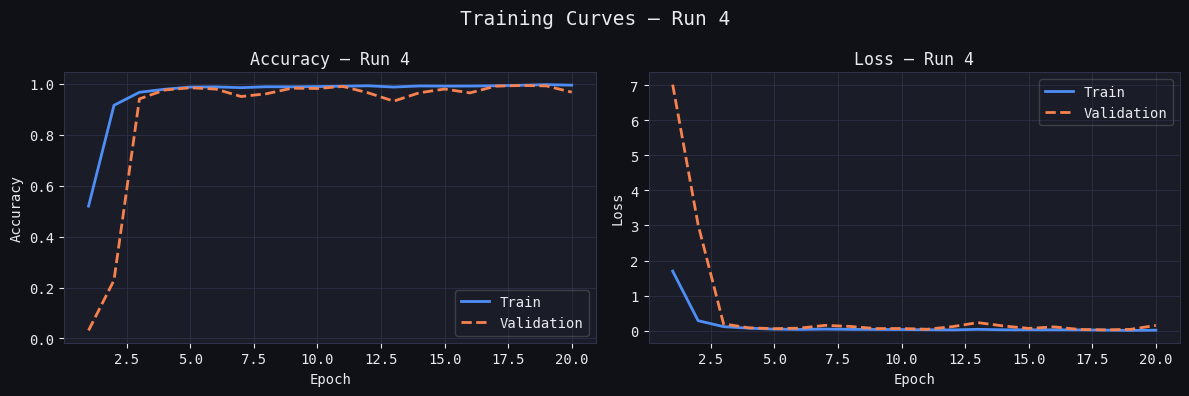

  ✅ saved → /kaggle/working/training_curves_run4.png


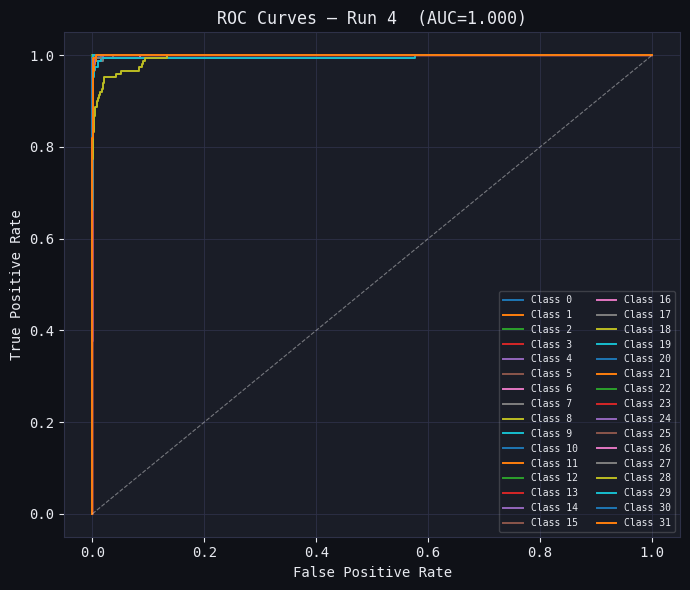

  ✅ saved → /kaggle/working/roc_run4.png


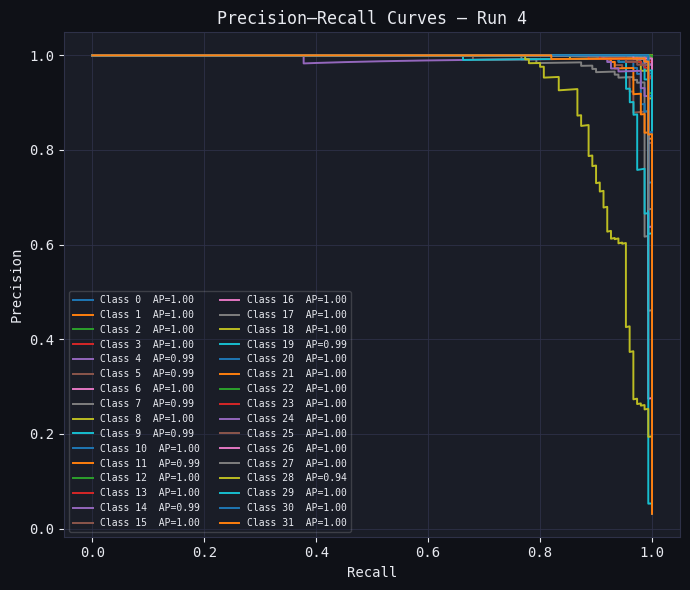

  ✅ saved → /kaggle/working/pr_run4.png

────────────────────────────────────────
  Run 5/10
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
352/352 - 28s - 80ms/step - accuracy: 0.5473 - loss: 1.5984 - val_accuracy: 0.0314 - val_loss: 6.0665
Epoch 2/20
352/352 - 8s - 23ms/step - accuracy: 0.9198 - loss: 0.2751 - val_accuracy: 0.2825 - val_loss: 2.5673
Epoch 3/20
352/352 - 8s - 22ms/step - accuracy: 0.9710 - loss: 0.1061 - val_accuracy: 0.9792 - val_loss: 0.0825
Epoch 4/20
352/352 - 8s - 22ms/step - accuracy: 0.9851 - loss: 0.0588 - val_accuracy: 0.9838 - val_loss: 0.0564
Epoch 5/20
352/352 - 8s - 22ms/step - accuracy: 0.9898 - loss: 0.0394 - val_accuracy: 0.9906 - val_loss: 0.0466
Epoch 6/20
352/352 - 8s - 22ms/step - accuracy: 0.9863 - loss: 0.0489 - val_accuracy: 0.9821 - val_loss: 0.0609
Epoch 7/20
352/352 - 8s - 22ms/step - accuracy: 0.9916 - loss: 0.0326 - val_accuracy: 0.9890 - val_loss: 0.0383
Epoch 8/20
352/352 - 8s - 22ms/step - accuracy: 0.9901 - loss: 0.0343 - val_accuracy: 0.9638 - val_loss: 0.1090
Epoch 9/20
352/352 - 8s - 23ms/step - accuracy: 0.9840 - loss: 0.0538 - val_accuracy: 0.9863 - val_loss

  💾 Test probs saved → /kaggle/working/test_probs_run5.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run5.h5


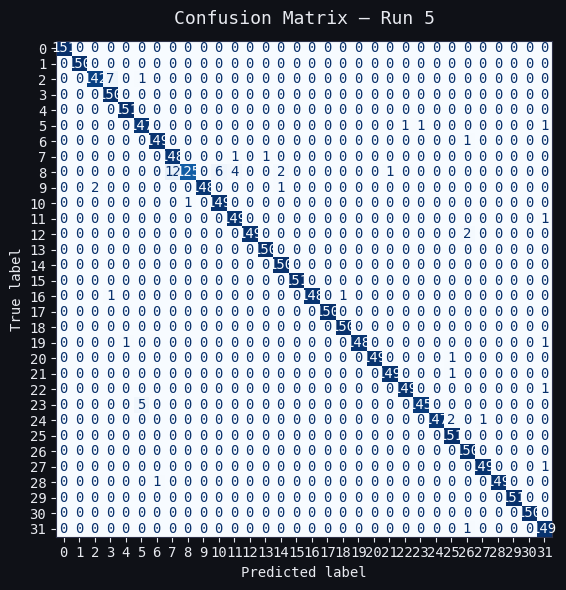

  ✅ saved → /kaggle/working/confusion_matrix_run5.png


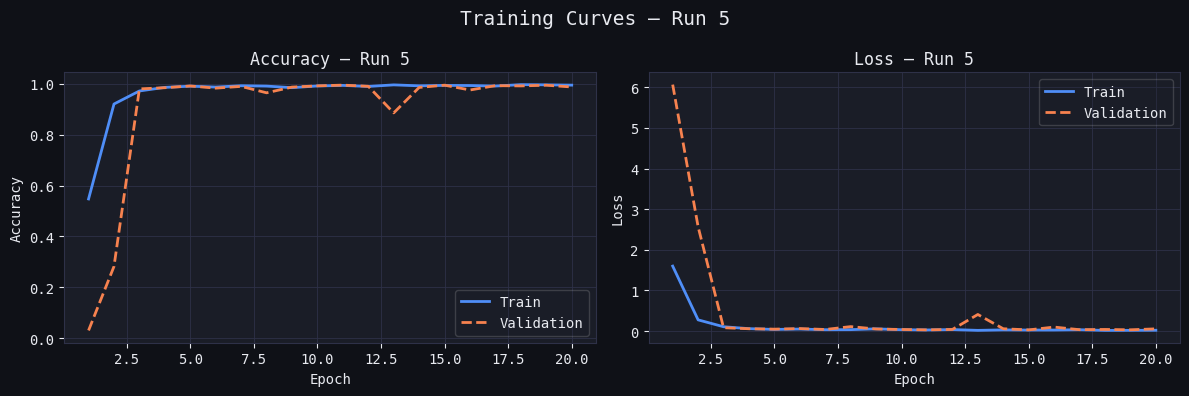

  ✅ saved → /kaggle/working/training_curves_run5.png


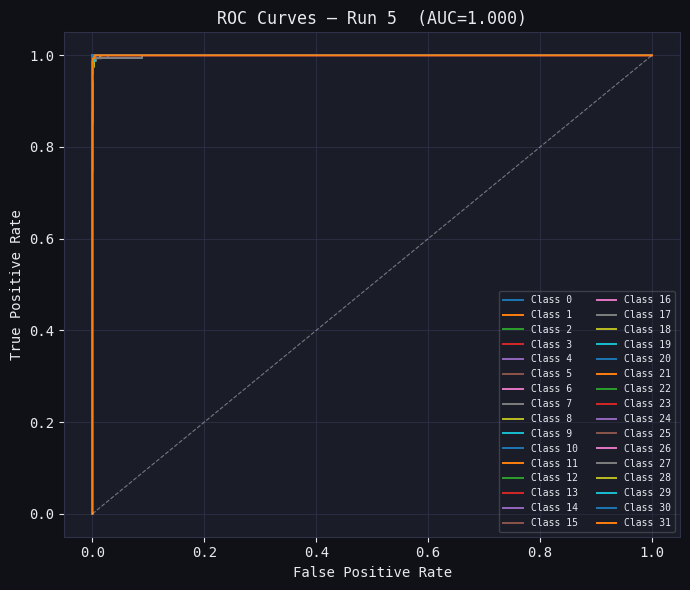

  ✅ saved → /kaggle/working/roc_run5.png


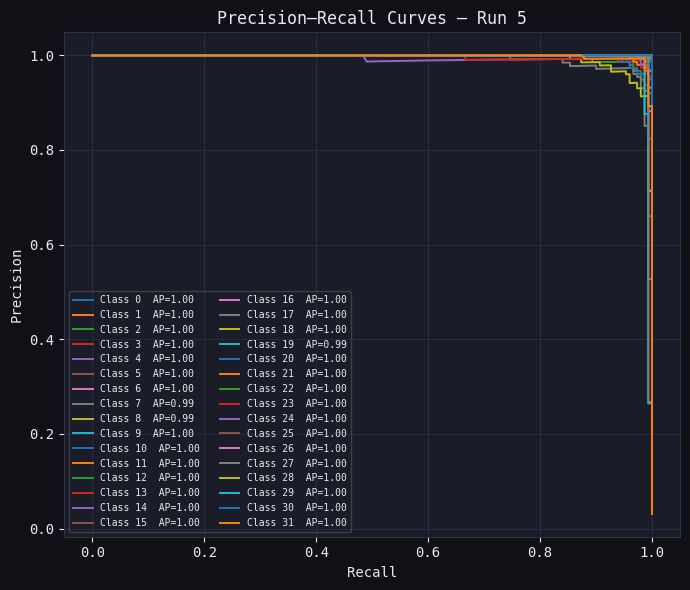

  ✅ saved → /kaggle/working/pr_run5.png

────────────────────────────────────────
  Run 6/10
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
352/352 - 26s - 74ms/step - accuracy: 0.5342 - loss: 1.6514 - val_accuracy: 0.0314 - val_loss: 4.8909
Epoch 2/20
352/352 - 8s - 22ms/step - accuracy: 0.9108 - loss: 0.2973 - val_accuracy: 0.2702 - val_loss: 2.5956
Epoch 3/20
352/352 - 8s - 22ms/step - accuracy: 0.9665 - loss: 0.1167 - val_accuracy: 0.9750 - val_loss: 0.0852
Epoch 4/20
352/352 - 8s - 22ms/step - accuracy: 0.9816 - loss: 0.0660 - val_accuracy: 0.9784 - val_loss: 0.0714
Epoch 5/20
352/352 - 8s - 22ms/step - accuracy: 0.9868 - loss: 0.0493 - val_accuracy: 0.9725 - val_loss: 0.0897
Epoch 6/20
352/352 - 8s - 22ms/step - accuracy: 0.9880 - loss: 0.0440 - val_accuracy: 0.9817 - val_loss: 0.0595
Epoch 7/20
352/352 - 8s - 22ms/step - accuracy: 0.9883 - loss: 0.0413 - val_accuracy: 0.9673 - val_loss: 0.1036
Epoch 8/20
352/352 - 8s - 22ms/step - accuracy: 0.9844 - loss: 0.0517 - val_accuracy: 0.9723 - val_loss: 0.1026
Epoch 9/20
352/352 - 8s - 22ms/step - accuracy: 0.9885 - loss: 0.0408 - val_accuracy: 0.9798 - val_loss

  💾 Test probs saved → /kaggle/working/test_probs_run6.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run6.h5


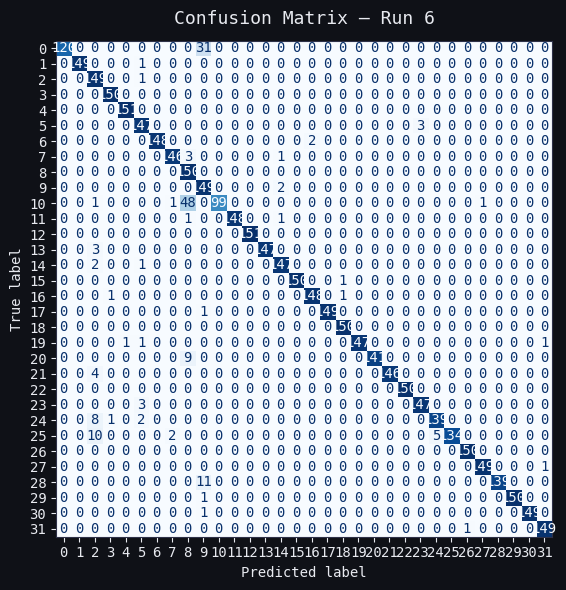

  ✅ saved → /kaggle/working/confusion_matrix_run6.png


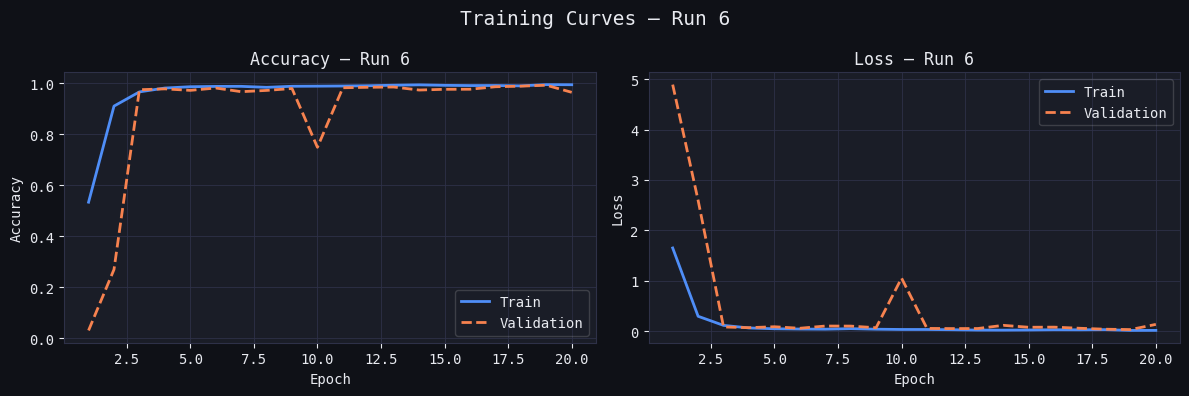

  ✅ saved → /kaggle/working/training_curves_run6.png


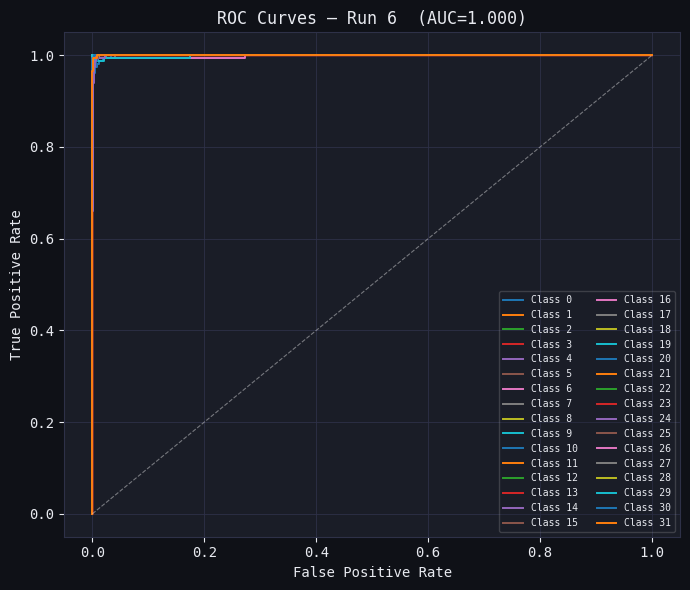

  ✅ saved → /kaggle/working/roc_run6.png


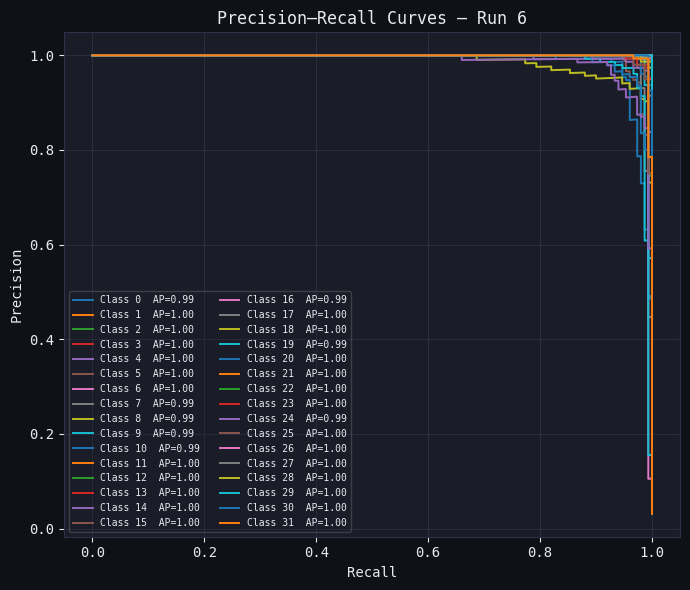

  ✅ saved → /kaggle/working/pr_run6.png

────────────────────────────────────────
  Run 7/10
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
352/352 - 28s - 78ms/step - accuracy: 0.5470 - loss: 1.6103 - val_accuracy: 0.0314 - val_loss: 5.6526
Epoch 2/20
352/352 - 8s - 22ms/step - accuracy: 0.9200 - loss: 0.2675 - val_accuracy: 0.1806 - val_loss: 3.0867
Epoch 3/20
352/352 - 8s - 22ms/step - accuracy: 0.9711 - loss: 0.1037 - val_accuracy: 0.9859 - val_loss: 0.0575
Epoch 4/20
352/352 - 8s - 22ms/step - accuracy: 0.9820 - loss: 0.0650 - val_accuracy: 0.9875 - val_loss: 0.0497
Epoch 5/20
352/352 - 8s - 22ms/step - accuracy: 0.9866 - loss: 0.0474 - val_accuracy: 0.9588 - val_loss: 0.1315
Epoch 6/20
352/352 - 8s - 22ms/step - accuracy: 0.9867 - loss: 0.0463 - val_accuracy: 0.9854 - val_loss: 0.0574
Epoch 7/20
352/352 - 8s - 22ms/step - accuracy: 0.9884 - loss: 0.0397 - val_accuracy: 0.9397 - val_loss: 0.1942
Epoch 8/20
352/352 - 8s - 22ms/step - accuracy: 0.9864 - loss: 0.0453 - val_accuracy: 0.9771 - val_loss: 0.0778
Epoch 9/20
352/352 - 8s - 22ms/step - accuracy: 0.9893 - loss: 0.0358 - val_accuracy: 0.9844 - val_loss

  💾 Test probs saved → /kaggle/working/test_probs_run7.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run7.h5


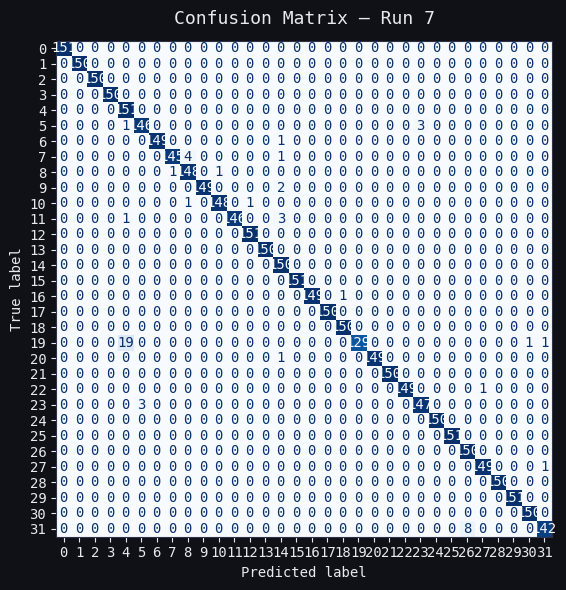

  ✅ saved → /kaggle/working/confusion_matrix_run7.png


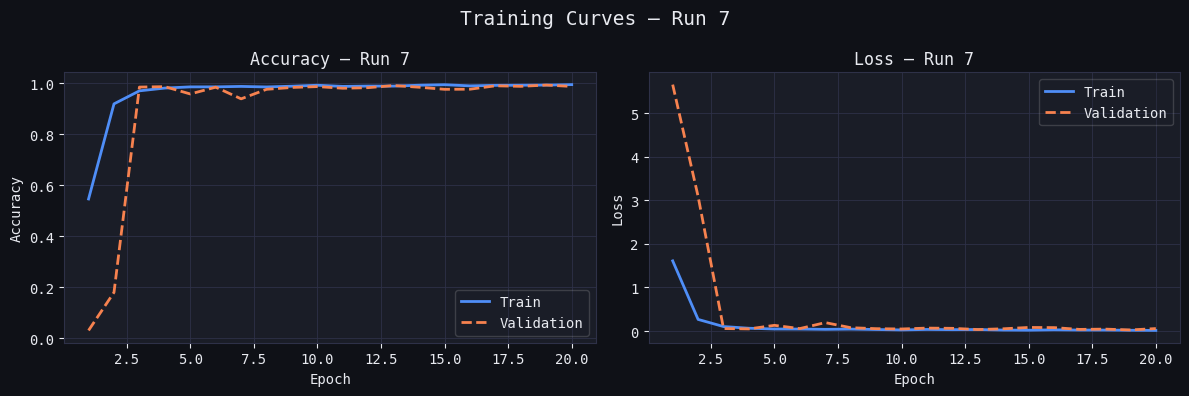

  ✅ saved → /kaggle/working/training_curves_run7.png


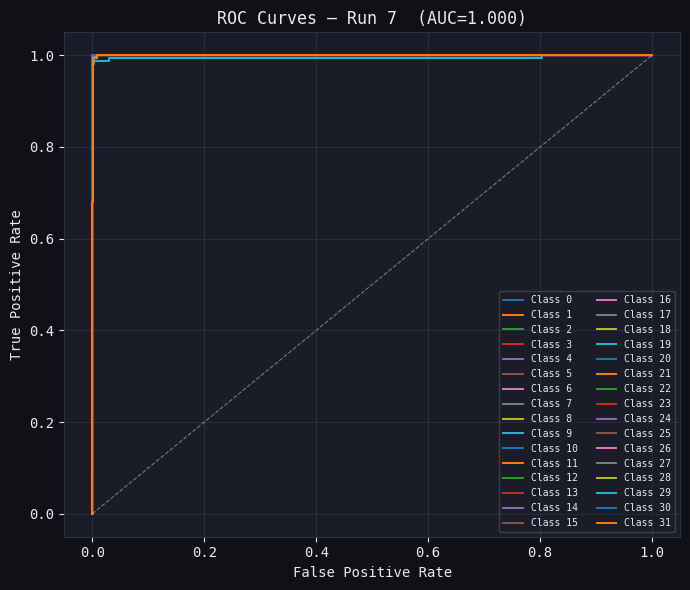

  ✅ saved → /kaggle/working/roc_run7.png


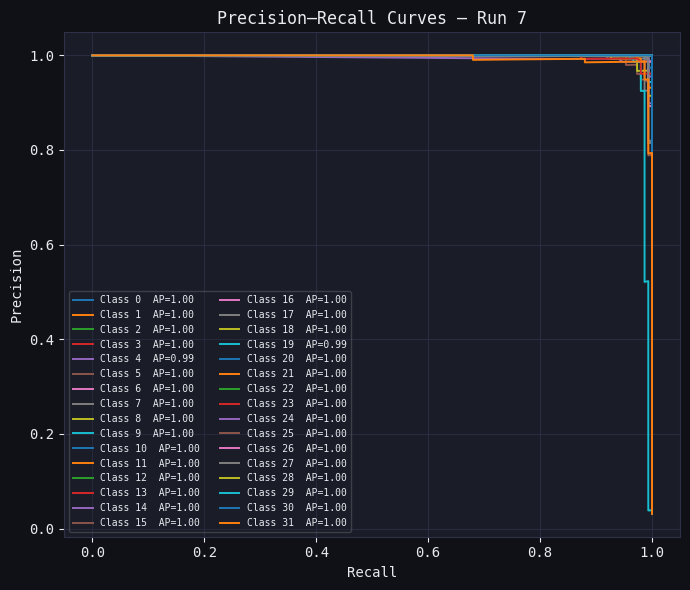

  ✅ saved → /kaggle/working/pr_run7.png

────────────────────────────────────────
  Run 8/10
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
352/352 - 26s - 75ms/step - accuracy: 0.5392 - loss: 1.6399 - val_accuracy: 0.0312 - val_loss: 5.4675
Epoch 2/20
352/352 - 8s - 23ms/step - accuracy: 0.9163 - loss: 0.2794 - val_accuracy: 0.3252 - val_loss: 2.3034
Epoch 3/20
352/352 - 8s - 23ms/step - accuracy: 0.9714 - loss: 0.1048 - val_accuracy: 0.9875 - val_loss: 0.0576
Epoch 4/20
352/352 - 8s - 23ms/step - accuracy: 0.9840 - loss: 0.0593 - val_accuracy: 0.9846 - val_loss: 0.0620
Epoch 5/20
352/352 - 8s - 23ms/step - accuracy: 0.9870 - loss: 0.0488 - val_accuracy: 0.9748 - val_loss: 0.0792
Epoch 6/20
352/352 - 8s - 23ms/step - accuracy: 0.9872 - loss: 0.0426 - val_accuracy: 0.9838 - val_loss: 0.0638
Epoch 7/20
352/352 - 8s - 23ms/step - accuracy: 0.9894 - loss: 0.0388 - val_accuracy: 0.9911 - val_loss: 0.0343
Epoch 8/20
352/352 - 8s - 22ms/step - accuracy: 0.9887 - loss: 0.0399 - val_accuracy: 0.9906 - val_loss: 0.0365
Epoch 9/20
352/352 - 8s - 22ms/step - accuracy: 0.9895 - loss: 0.0372 - val_accuracy: 0.9871 - val_loss

  💾 Test probs saved → /kaggle/working/test_probs_run8.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run8.h5


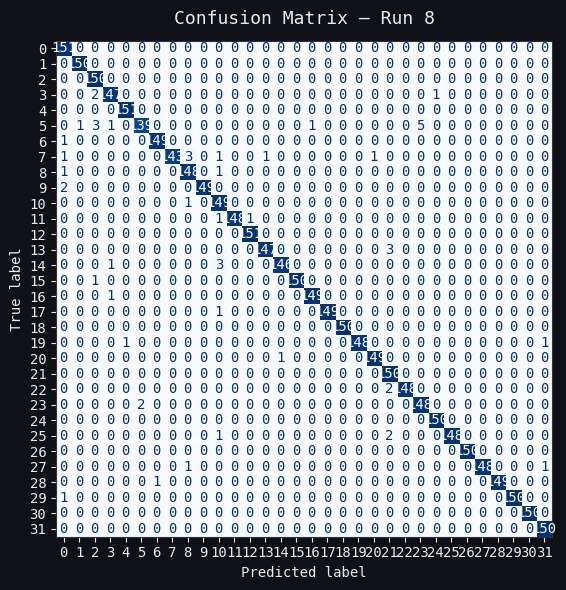

  ✅ saved → /kaggle/working/confusion_matrix_run8.png


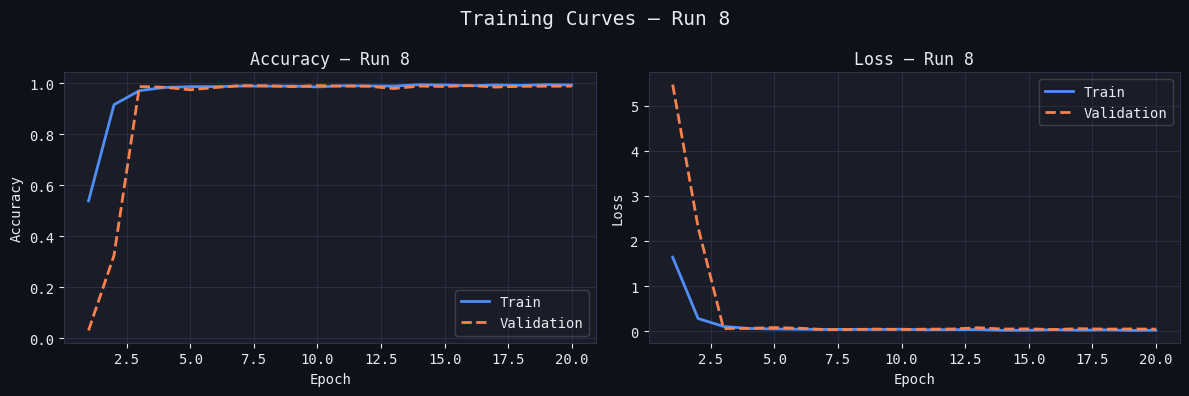

  ✅ saved → /kaggle/working/training_curves_run8.png


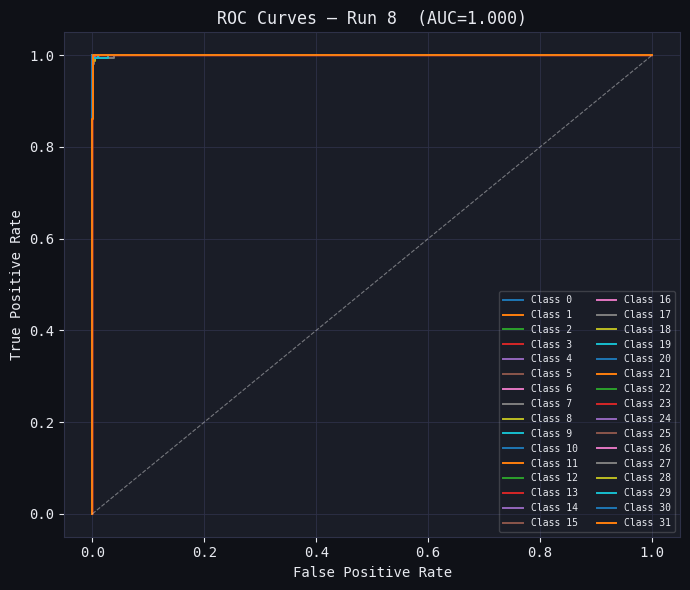

  ✅ saved → /kaggle/working/roc_run8.png


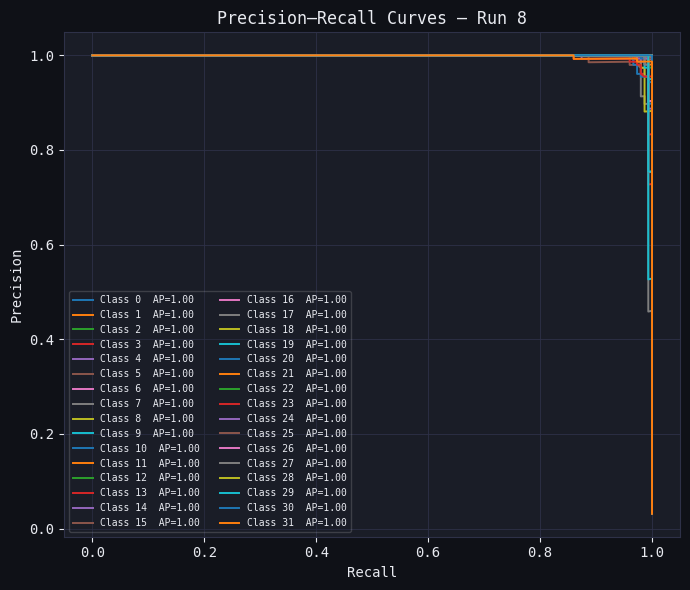

  ✅ saved → /kaggle/working/pr_run8.png

────────────────────────────────────────
  Run 9/10
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
352/352 - 27s - 76ms/step - accuracy: 0.5588 - loss: 1.5649 - val_accuracy: 0.0312 - val_loss: 5.2028
Epoch 2/20
352/352 - 8s - 22ms/step - accuracy: 0.9183 - loss: 0.2730 - val_accuracy: 0.3643 - val_loss: 2.2137
Epoch 3/20
352/352 - 8s - 22ms/step - accuracy: 0.9678 - loss: 0.1106 - val_accuracy: 0.9719 - val_loss: 0.1213
Epoch 4/20
352/352 - 8s - 22ms/step - accuracy: 0.9840 - loss: 0.0570 - val_accuracy: 0.9850 - val_loss: 0.0547
Epoch 5/20
352/352 - 8s - 22ms/step - accuracy: 0.9880 - loss: 0.0441 - val_accuracy: 0.9846 - val_loss: 0.0528
Epoch 6/20
352/352 - 8s - 22ms/step - accuracy: 0.9864 - loss: 0.0488 - val_accuracy: 0.9361 - val_loss: 0.2147
Epoch 7/20
352/352 - 8s - 23ms/step - accuracy: 0.9868 - loss: 0.0450 - val_accuracy: 0.9653 - val_loss: 0.1344
Epoch 8/20
352/352 - 8s - 23ms/step - accuracy: 0.9857 - loss: 0.0508 - val_accuracy: 0.9836 - val_loss: 0.0593
Epoch 9/20
352/352 - 8s - 23ms/step - accuracy: 0.9929 - loss: 0.0254 - val_accuracy: 0.9848 - val_loss

  💾 Test probs saved → /kaggle/working/test_probs_run9.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run9.h5


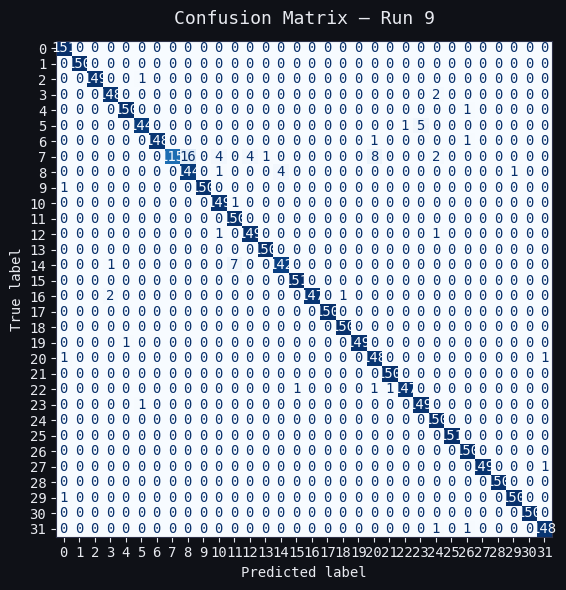

  ✅ saved → /kaggle/working/confusion_matrix_run9.png


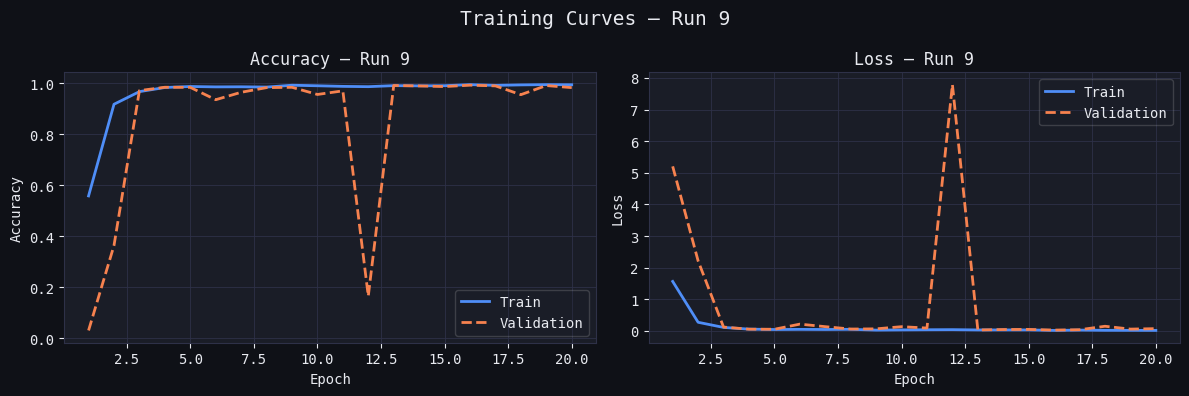

  ✅ saved → /kaggle/working/training_curves_run9.png


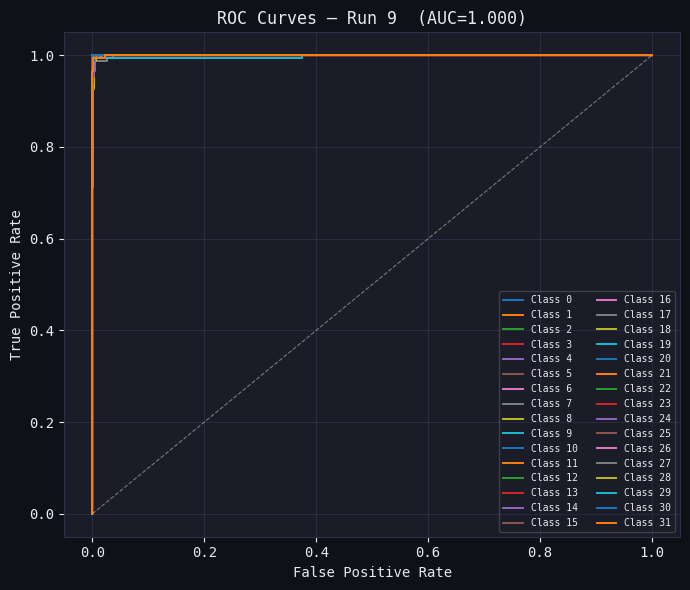

  ✅ saved → /kaggle/working/roc_run9.png


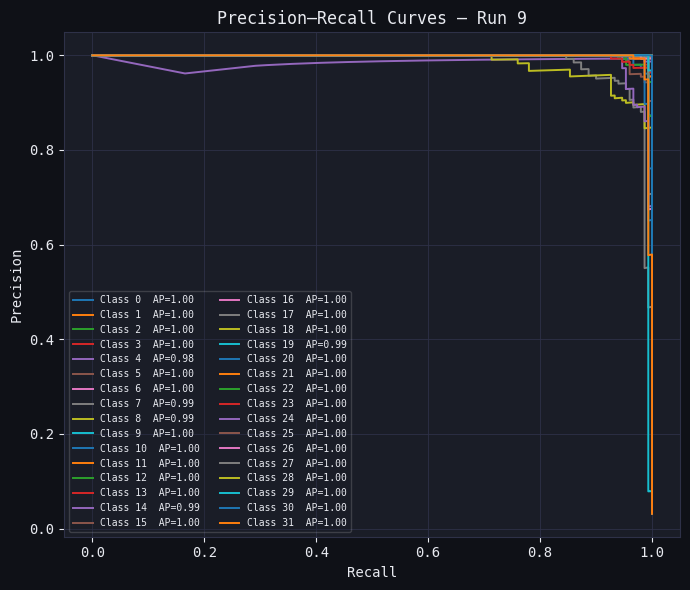

  ✅ saved → /kaggle/working/pr_run9.png

────────────────────────────────────────
  Run 10/10
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
352/352 - 28s - 80ms/step - accuracy: 0.5247 - loss: 1.6607 - val_accuracy: 0.0312 - val_loss: 5.8102
Epoch 2/20
352/352 - 8s - 24ms/step - accuracy: 0.9150 - loss: 0.2846 - val_accuracy: 0.3969 - val_loss: 1.9533
Epoch 3/20
352/352 - 8s - 23ms/step - accuracy: 0.9661 - loss: 0.1135 - val_accuracy: 0.9859 - val_loss: 0.0586
Epoch 4/20
352/352 - 8s - 23ms/step - accuracy: 0.9822 - loss: 0.0633 - val_accuracy: 0.9817 - val_loss: 0.0633
Epoch 5/20
352/352 - 8s - 23ms/step - accuracy: 0.9889 - loss: 0.0409 - val_accuracy: 0.9896 - val_loss: 0.0419
Epoch 6/20
352/352 - 8s - 22ms/step - accuracy: 0.9872 - loss: 0.0465 - val_accuracy: 0.4217 - val_loss: 2.5045
Epoch 7/20
352/352 - 8s - 22ms/step - accuracy: 0.9884 - loss: 0.0424 - val_accuracy: 0.9831 - val_loss: 0.0596
Epoch 8/20
352/352 - 8s - 22ms/step - accuracy: 0.9884 - loss: 0.0384 - val_accuracy: 0.9788 - val_loss: 0.0708
Epoch 9/20
352/352 - 8s - 22ms/step - accuracy: 0.9888 - loss: 0.0416 - val_accuracy: 0.9755 - val_loss

  💾 Test probs saved → /kaggle/working/test_probs_run10.npy  shape: (4820, 32)
  💾 Model saved    → /kaggle/working/model_run10.h5


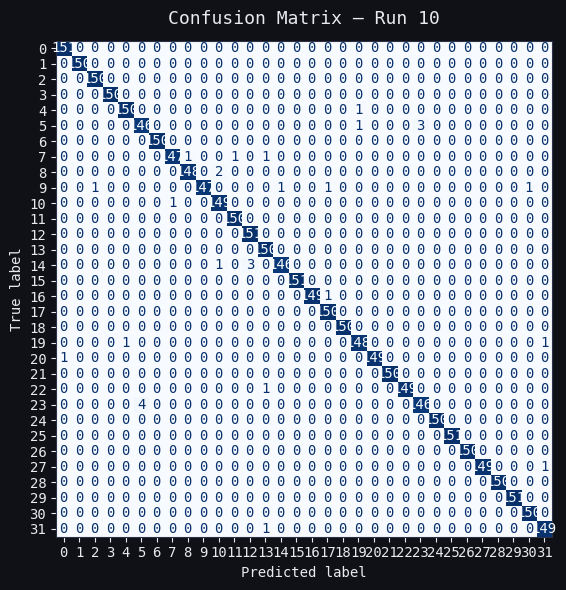

  ✅ saved → /kaggle/working/confusion_matrix_run10.png


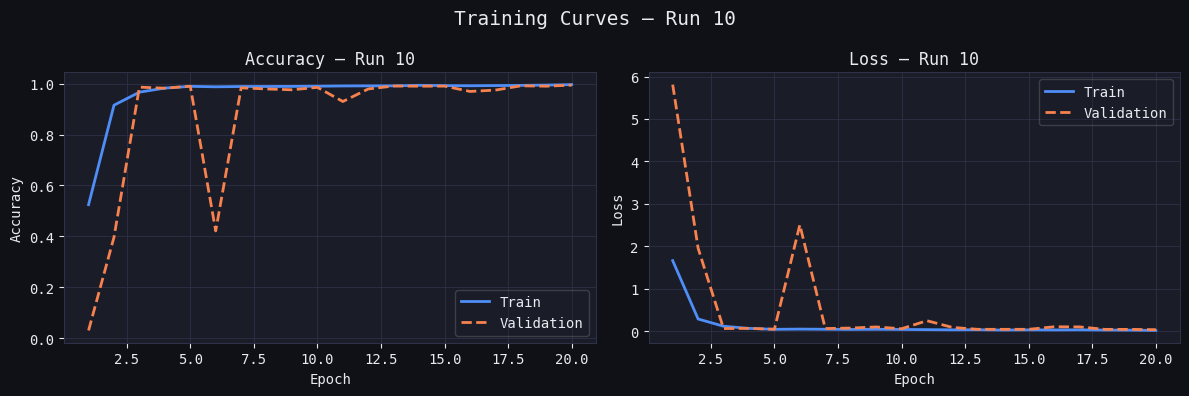

  ✅ saved → /kaggle/working/training_curves_run10.png


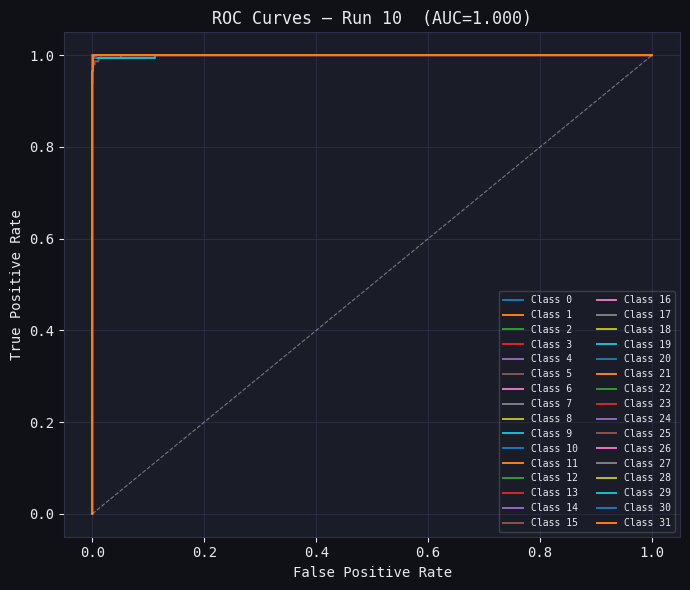

  ✅ saved → /kaggle/working/roc_run10.png


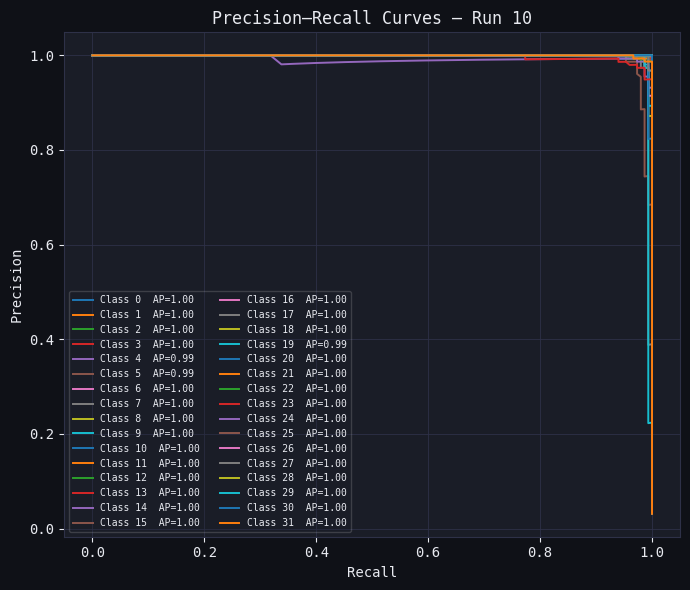

  ✅ saved → /kaggle/working/pr_run10.png

═══════════════════════════════════════════════════════
  ✅ cnn_test_probs.npy saved → /kaggle/working/cnn_test_probs.npy
  📐 Shape: (4820, 32)
     ↑ (4820 samples × 32 classes)
  🎯 جاهز للـ Ensemble مع باقي الموديلات
  ✔ Probs sum check — min: 1.0000  max: 1.0000  (المفروض ≈ 1.0)
═══════════════════════════════════════════════════════


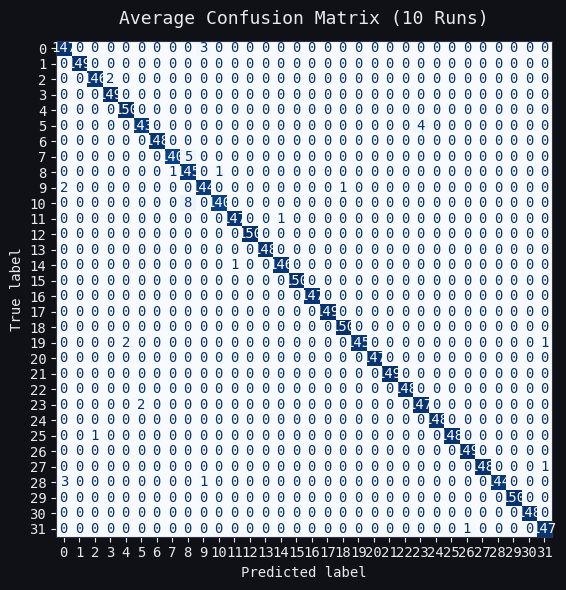

  ✅ saved → /kaggle/working/confusion_matrix_avg.png


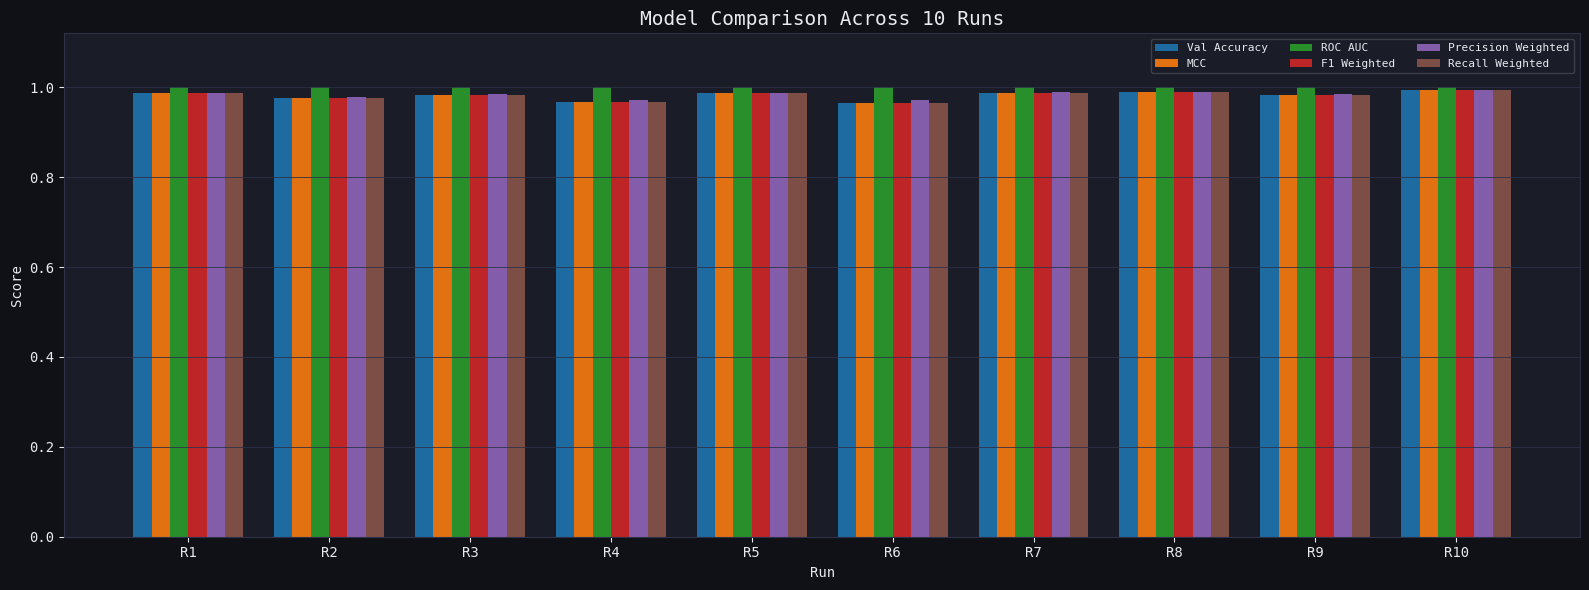

  ✅ saved → /kaggle/working/model_comparison_bar.png


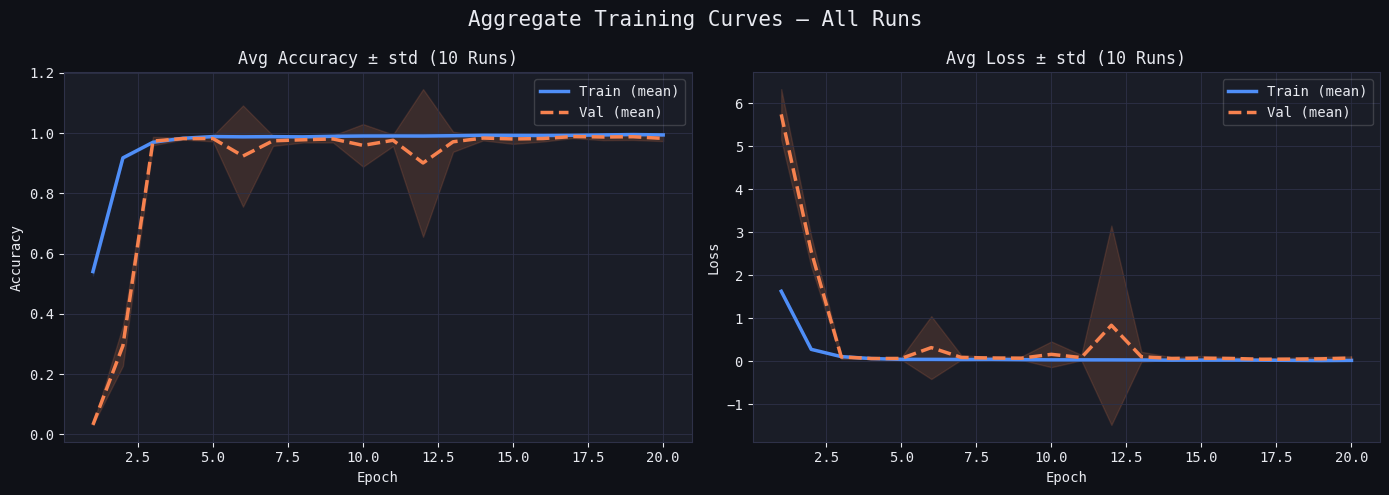

  ✅ saved → /kaggle/working/aggregate_training_curves.png


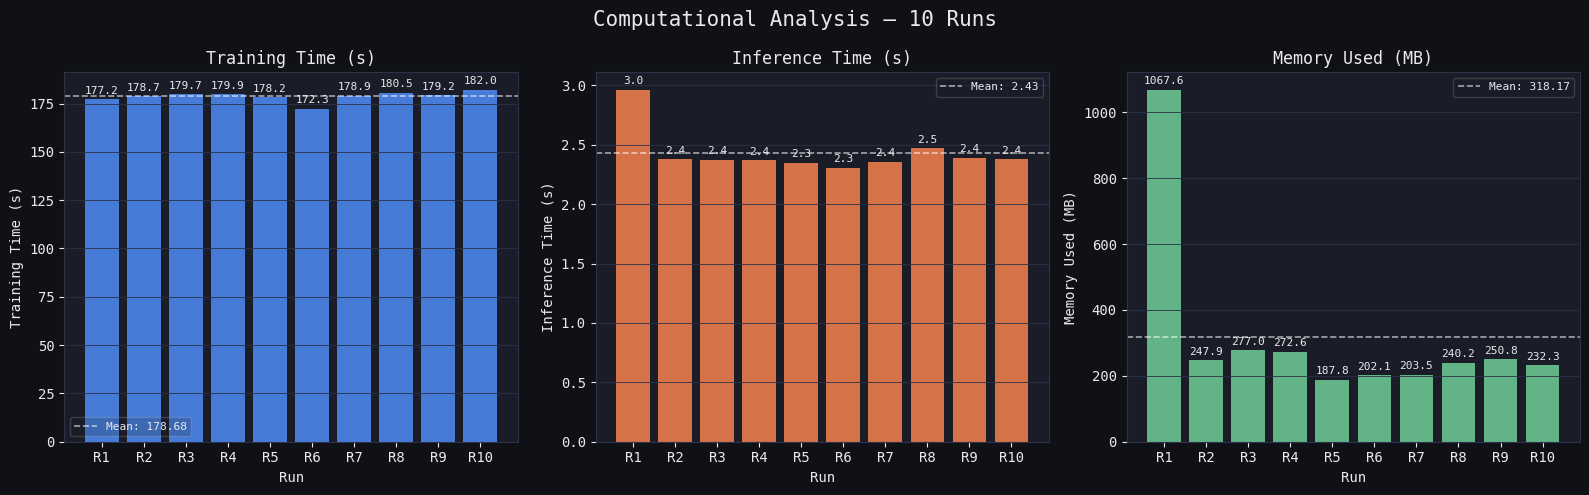

  ✅ saved → /kaggle/working/computational_analysis.png


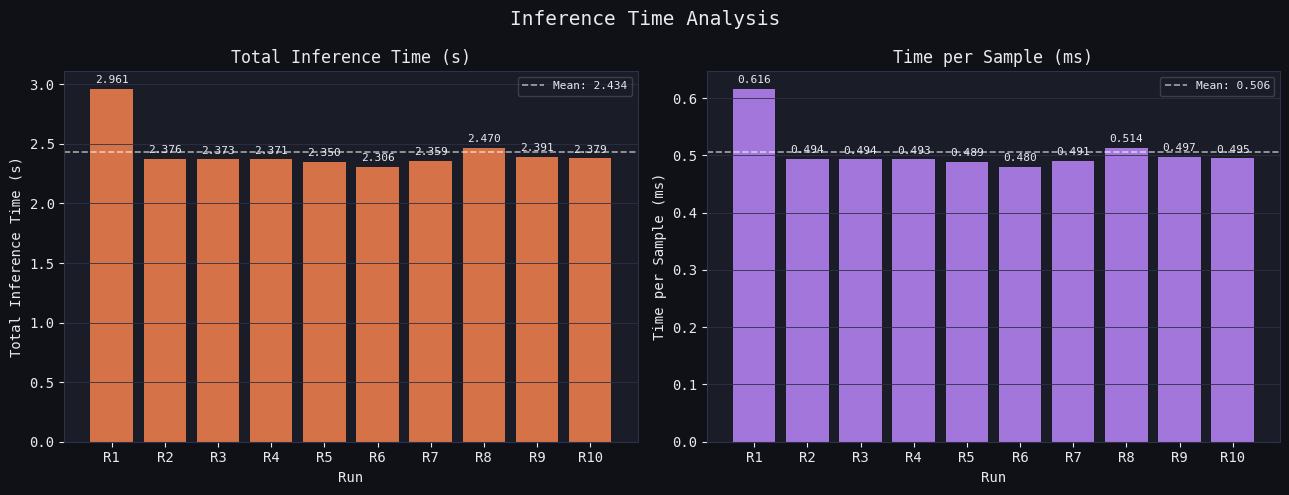

  ✅ saved → /kaggle/working/inference_time_analysis.png


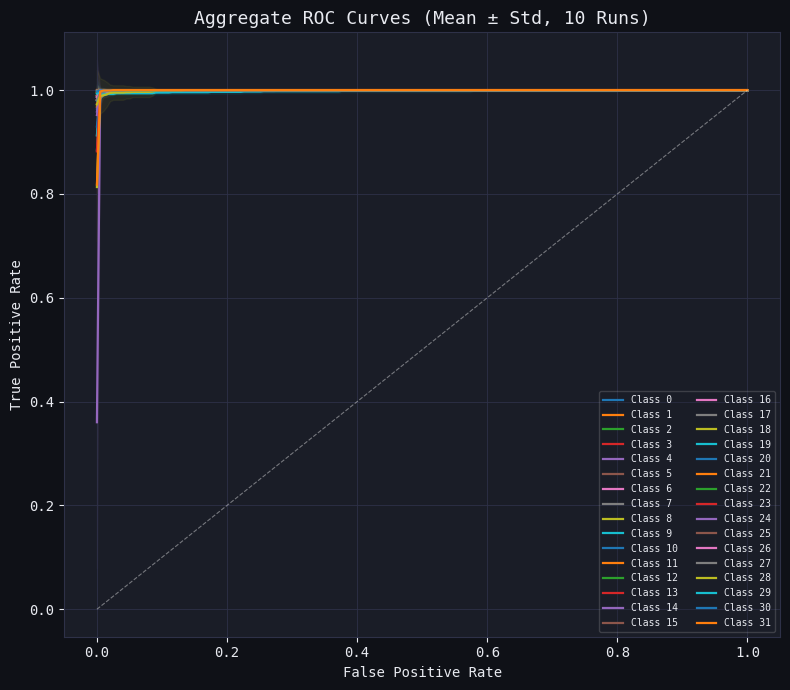

  ✅ saved → /kaggle/working/roc_aggregate.png


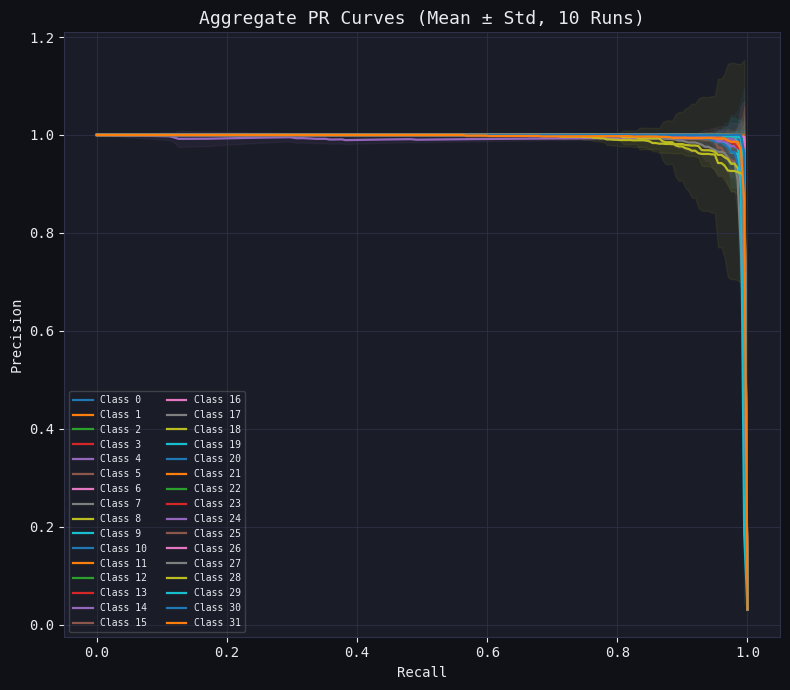

  ✅ saved → /kaggle/working/pr_aggregate.png


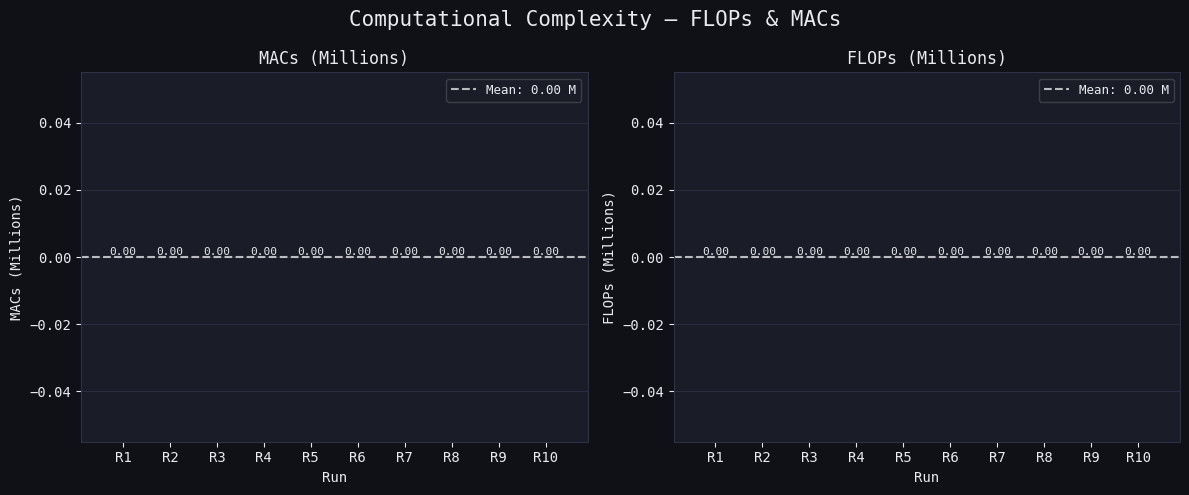

  ✅ saved → /kaggle/working/flops_macs_analysis.png


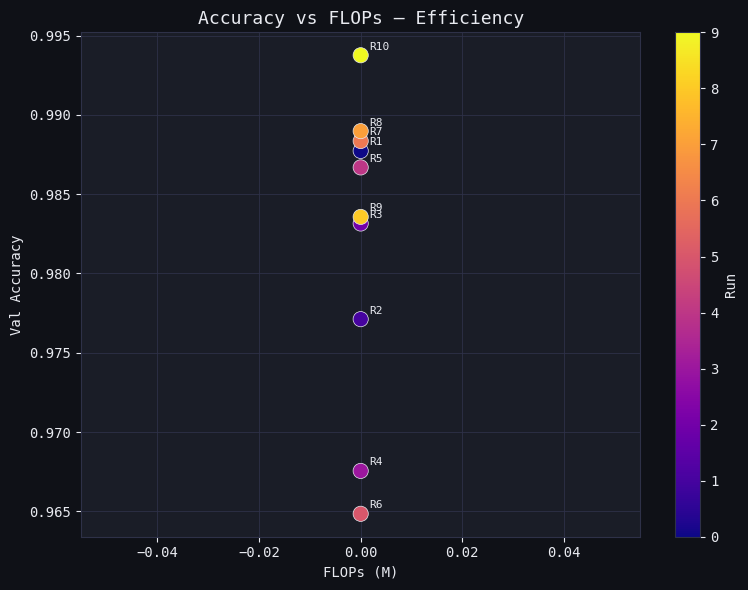

  ✅ saved → /kaggle/working/accuracy_vs_flops.png


/tmp/ipykernel_57/1726126236.py:534: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


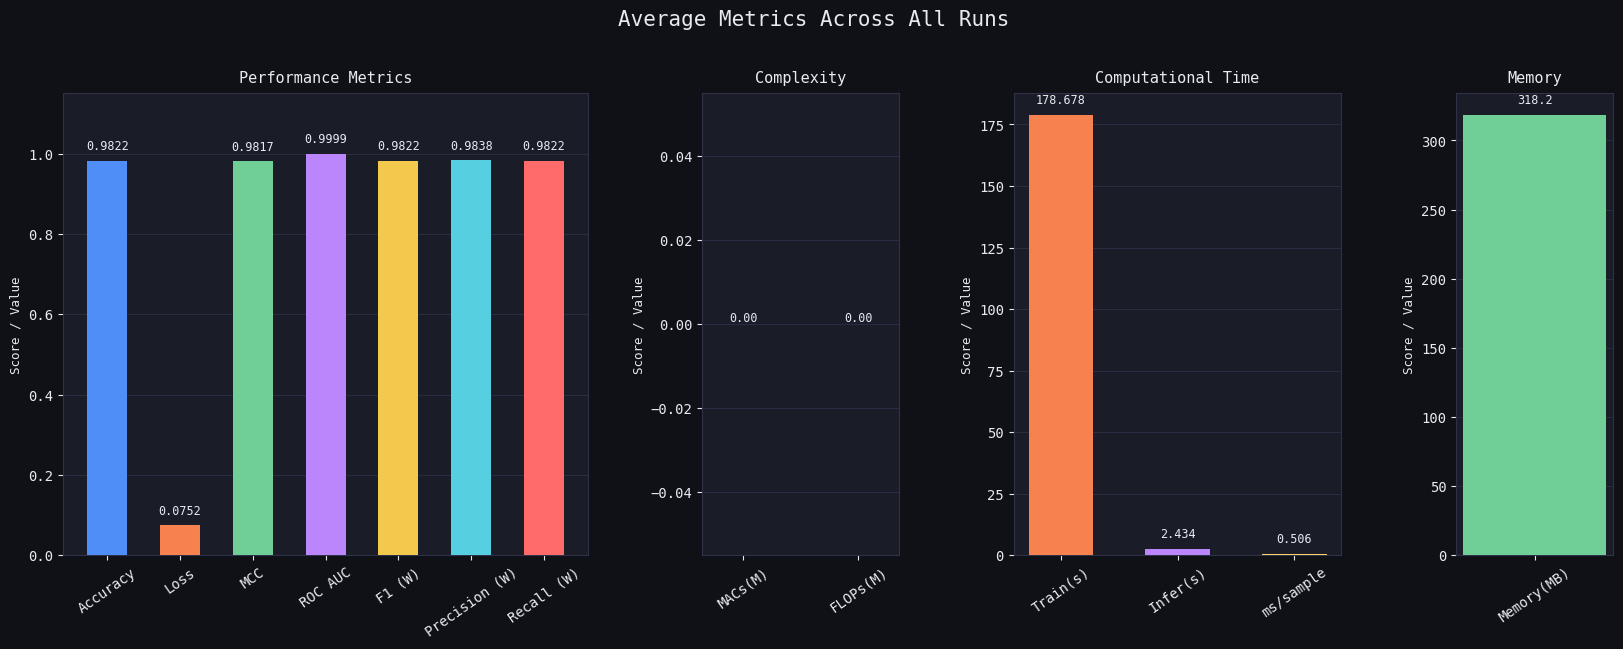

  ✅ saved → /kaggle/working/avg_metrics_bars.png


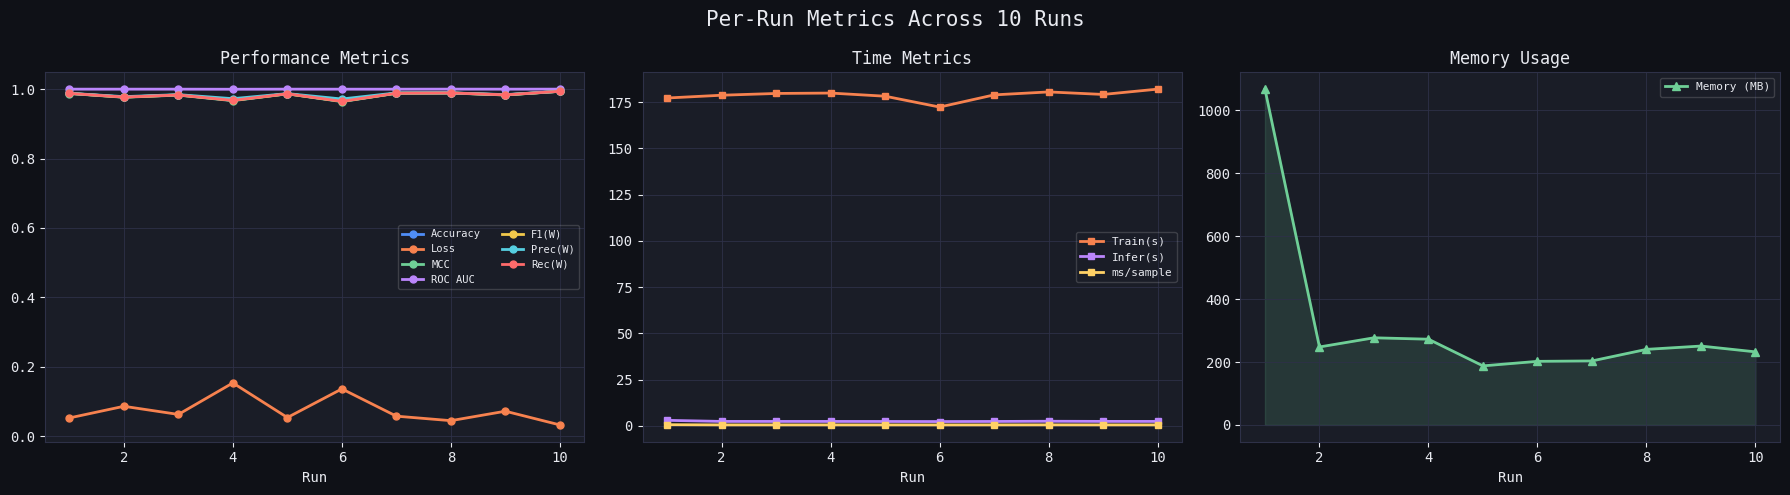

  ✅ saved → /kaggle/working/per_run_metrics.png


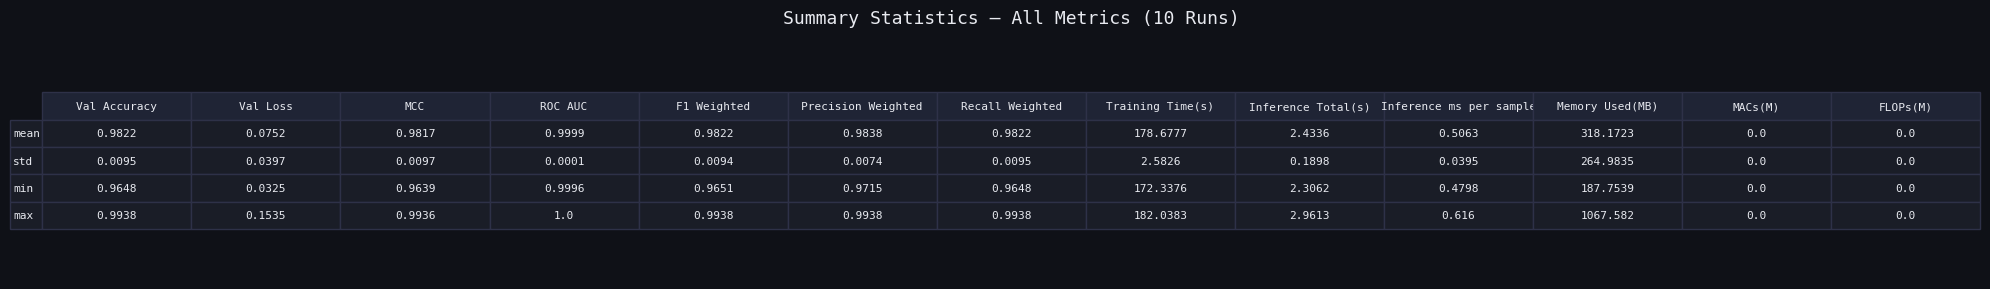

  ✅ saved → /kaggle/working/summary_stats_table.png

  💾 Excel saved → /kaggle/working/cnn_full_analysis.xlsx

  📊 Average Results (10 Runs):
  Accuracy              : 0.9822
  Loss                  : 0.0752
  MCC                   : 0.9817
  ROC AUC               : 0.9999
  F1 (W)                : 0.9822
  Precision (W)         : 0.9838
  Recall (W)            : 0.9822
  Train Time (s)        : 178.6777
  Infer Total (s)       : 2.4336
  ms / sample           : 0.5063
  Memory (MB)           : 318.1723
  MACs (M)              : 0.0000
  FLOPs (M)             : 0.0000

  🎯 Ensemble-Ready:
  cnn_test_probs.npy  →  shape: (4820, 32)
  الاستخدام:
    cnn_probs    = np.load('cnn_test_probs.npy')
    mob_probs    = np.load('mob_test_probs.npy')
    ensemble     = (cnn_probs + mob_probs) / 2


In [6]:
import gc, time, os, psutil
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    matthews_corrcoef, roc_auc_score,
    f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow.keras.backend as K

# ── colour palette ──────────────────────────────────────────────────────────
PALETTE = plt.cm.tab10.colors
BG      = "#0f1117"
CARD    = "#1a1d27"
ACCENT  = "#4f8ef7"
TEXT    = "#e8eaf0"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "axes.edgecolor": "#2e3148", "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": "#2e3148",
    "grid.linewidth": 0.6, "font.family": "monospace",
})

SAVE_DIR = "/kaggle/working/"
os.makedirs(SAVE_DIR, exist_ok=True)

def save(name):
    path = os.path.join(SAVE_DIR, name)
    plt.savefig(path, dpi=120, bbox_inches='tight', facecolor=BG)
    plt.show()
    plt.close()
    print(f"  ✅ saved → {path}")

# ══════════════════════════════════════════════════════════════════════════════
#  FLOPs & MACs — حساب يدوي من layers
# ══════════════════════════════════════════════════════════════════════════════
def compute_flops_macs(model):
    """
    بيحسب MACs و FLOPs من layers الموديل يدوياً
    - Conv2D       : H_out × W_out × C_out × (kH × kW × C_in)
    - DepthwiseConv: H_out × W_out × C     × (kH × kW)
    - Dense        : in_units × out_units
    - FLOPs = MACs × 2  (multiply + accumulate = 2 ops)
    """
    total_macs = 0
    for layer in model.layers:
        try:
            cfg = layer.get_config()

            if isinstance(layer, tf.keras.layers.Conv2D):
                out_shape = layer.output_shape          # (None, H, W, C_out)
                if len(out_shape) == 4:
                    _, H, W, C_out = out_shape
                    k = cfg['kernel_size']
                    kH, kW = (k, k) if isinstance(k, int) else tuple(k)
                    C_in = layer.input_shape[-1]
                    total_macs += H * W * C_out * kH * kW * C_in

            elif isinstance(layer, tf.keras.layers.DepthwiseConv2D):
                out_shape = layer.output_shape
                if len(out_shape) == 4:
                    _, H, W, C = out_shape
                    k = cfg['kernel_size']
                    kH, kW = (k, k) if isinstance(k, int) else tuple(k)
                    total_macs += H * W * C * kH * kW

            elif isinstance(layer, tf.keras.layers.Dense):
                in_units  = layer.input_shape[-1]
                out_units = cfg['units']
                total_macs += in_units * out_units

        except Exception:
            pass   # skip layers بدون output_shape واضح

    total_flops = total_macs * 2
    return total_flops, total_macs


# ══════════════════════════════════════════════════════════════════════════════
#  حساب FLOPs/MACs مرة واحدة قبل الـ loop (Architecture ثابتة)
# ══════════════════════════════════════════════════════════════════════════════
print("🔢 Calculating FLOPs & MACs...")
_tmp = build_cnn()
model_flops, model_macs = compute_flops_macs(_tmp)
del _tmp; K.clear_session(); gc.collect()

print(f"  MACs  : {model_macs / 1e6:.4f} M")
print(f"  FLOPs : {model_flops / 1e6:.4f} M")


# ── storage ──────────────────────────────────────────────────────────────────
num_runs             = 10
results              = []
all_histories        = []
all_y_pred           = []
all_y_pred_prob      = []
all_cms              = []
train_times_list     = []
inference_times_list = []
all_test_probs       = []   # ← test probs من كل run للـ ensemble


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN LOOP — 10 Runs
# ══════════════════════════════════════════════════════════════════════════════
for run in range(1, num_runs + 1):
    print(f"\n{'─'*40}\n  Run {run}/{num_runs}\n{'─'*40}")

    # ── training time & memory ───────────────────────────────────────────────
    start_time = time.time()
    start_mem  = psutil.Process().memory_info().rss / (1024 ** 2)

    model   = build_cnn()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=20, batch_size=64, verbose=2,
    )

    end_time     = time.time()
    end_mem      = psutil.Process().memory_info().rss / (1024 ** 2)
    train_time   = end_time - start_time
    train_memory = end_mem - start_mem
    train_times_list.append(train_time)

    # ── inference time — مع warm-up لدقة أكبر ───────────────────────────────
    _ = model.predict(x_val[:8], verbose=0)          # warm-up pass

    inf_start        = time.time()
    y_pred_prob      = model.predict(x_val, verbose=0)
    inf_end          = time.time()
    inference_time   = inf_end - inf_start            # total (s)
    inference_per_sample = inference_time / len(x_val) * 1000   # ms/sample
    inference_times_list.append(inference_time)

    y_pred = np.argmax(y_pred_prob, axis=1)

    # ── evaluate ─────────────────────────────────────────────────────────────
    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)

    # ── metrics ──────────────────────────────────────────────────────────────
    cm          = confusion_matrix(y_val, y_pred)
    mcc         = matthews_corrcoef(y_val, y_pred)
    y_val_bin   = label_binarize(y_val, classes=np.arange(num_classes))
    try:
        roc_auc = roc_auc_score(y_val_bin, y_pred_prob, average='macro', multi_class='ovr')
    except Exception:
        roc_auc = np.nan
    f1_w        = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w    = recall_score(y_val, y_pred, average='weighted')

    print(f"  Val Acc: {val_acc:.4f}  |  Val Loss: {val_loss:.4f}")
    print(f"  MCC: {mcc:.4f}  |  ROC AUC: {roc_auc:.4f}")
    print(f"  F1(W): {f1_w:.4f}  |  Prec(W): {precision_w:.4f}  |  Rec(W): {recall_w:.4f}")
    print(f"  Train: {train_time:.2f}s  |  Infer Total: {inference_time:.4f}s"
          f"  |  Infer/sample: {inference_per_sample:.4f} ms  |  Mem: {train_memory:.2f} MB")
    print(f"  MACs: {model_macs/1e6:.4f} M  |  FLOPs: {model_flops/1e6:.4f} M")

    # ── test probabilities per sample ────────────────────────────────────────
    _ = model.predict(x_test[:8], verbose=0)          # warm-up
    test_probs = model.predict(x_test, verbose=0)     # shape: (N_test, num_classes)
    all_test_probs.append(test_probs)

    test_probs_path = os.path.join(SAVE_DIR, f"test_probs_run{run}.npy")
    np.save(test_probs_path, test_probs)
    print(f"  💾 Test probs saved → {test_probs_path}  shape: {test_probs.shape}")

    # ── save model ───────────────────────────────────────────────────────────
    model_path = os.path.join(SAVE_DIR, f"model_run{run}.h5")
    model.save(model_path)
    print(f"  💾 Model saved    → {model_path}")

    # ── save for aggregate plots ─────────────────────────────────────────────
    all_histories.append(history)
    all_y_pred.append(y_pred)
    all_y_pred_prob.append(y_pred_prob)
    all_cms.append(cm)

    results.append({
        'Run':                     run,
        'Val_Accuracy':            val_acc,
        'Val_Loss':                val_loss,
        'MCC':                     mcc,
        'ROC_AUC':                 roc_auc,
        'F1_Weighted':             f1_w,
        'Precision_Weighted':      precision_w,
        'Recall_Weighted':         recall_w,
        'Training_Time(s)':        train_time,
        'Inference_Total(s)':      inference_time,        # ← اسم أوضح
        'Inference_ms_per_sample': inference_per_sample,  # ← ms/sample
        'Memory_Used(MB)':         train_memory,
        'MACs(M)':                 model_macs  / 1e6,     # ← جديد
        'FLOPs(M)':                model_flops / 1e6,     # ← جديد
    })

    # ══════════════════════════════════════════════════════════════════════════
    #  PER-RUN PLOTS
    # ══════════════════════════════════════════════════════════════════════════

    # ── 1. Confusion Matrix ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — Run {run}", fontsize=13, color=TEXT, pad=12)
    for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
    plt.tight_layout()
    save(f"confusion_matrix_run{run}.png")

    # ── 2. Accuracy / Loss Curves ────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor(BG)
    epochs_range = range(1, len(history.history['accuracy']) + 1)
    for ax, metric, val_metric, ylabel in [
        (ax1, 'accuracy', 'val_accuracy', 'Accuracy'),
        (ax2, 'loss',     'val_loss',     'Loss'),
    ]:
        ax.set_facecolor(CARD)
        ax.plot(epochs_range, history.history[metric],
                color=ACCENT, lw=2, label='Train')
        ax.plot(epochs_range, history.history[val_metric],
                color='#f7824f', lw=2, linestyle='--', label='Validation')
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} — Run {run}", color=TEXT)
        ax.legend(framealpha=0.2); ax.grid(True)
        for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
    fig.suptitle(f"Training Curves — Run {run}", color=TEXT, fontsize=14)
    plt.tight_layout()
    save(f"training_curves_run{run}.png")

    # ── 3. ROC Curve ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_pred_prob[:, i])
        ax.plot(fpr, tpr, color=PALETTE[i % len(PALETTE)], lw=1.4, label=f"Class {i}")
    ax.plot([0, 1], [0, 1], 'w--', lw=0.8, alpha=0.4)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curves — Run {run}  (AUC={roc_auc:.3f})", color=TEXT)
    ax.legend(fontsize=7, framealpha=0.2, ncol=2); ax.grid(True)
    for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
    plt.tight_layout()
    save(f"roc_run{run}.png")

    # ── 4. PR Curve ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
    for i in range(num_classes):
        prec, rec, _ = precision_recall_curve(y_val_bin[:, i], y_pred_prob[:, i])
        ap = average_precision_score(y_val_bin[:, i], y_pred_prob[:, i])
        ax.plot(rec, prec, color=PALETTE[i % len(PALETTE)], lw=1.4,
                label=f"Class {i}  AP={ap:.2f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"Precision–Recall Curves — Run {run}", color=TEXT)
    ax.legend(fontsize=7, framealpha=0.2, ncol=2); ax.grid(True)
    for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
    plt.tight_layout()
    save(f"pr_run{run}.png")

    # ── تنظيف الميموري ───────────────────────────────────────────────────────
    del model, history, y_pred, y_pred_prob, test_probs
    K.clear_session()
    gc.collect()


# ══════════════════════════════════════════════════════════════════════════════
#  cnn_test_probs — average الـ 10 runs per sample للـ Ensemble
# ══════════════════════════════════════════════════════════════════════════════
# stack shape: (10, N_test, num_classes) → mean axis=0 → (N_test, num_classes)
# يعني: sample 0 = average الـ 10 runs للـ sample دي

cnn_test_probs = np.stack(all_test_probs, axis=0).mean(axis=0)

cnn_probs_path = os.path.join(SAVE_DIR, "cnn_test_probs.npy")
np.save(cnn_probs_path, cnn_test_probs)

print(f"\n{'═'*55}")
print(f"  ✅ cnn_test_probs.npy saved → {cnn_probs_path}")
print(f"  📐 Shape: {cnn_test_probs.shape}")
print(f"     ↑ ({cnn_test_probs.shape[0]} samples × {cnn_test_probs.shape[1]} classes)")
print(f"  🎯 جاهز للـ Ensemble مع باقي الموديلات")

sums = cnn_test_probs.sum(axis=1)
print(f"  ✔ Probs sum check — min: {sums.min():.4f}  max: {sums.max():.4f}  (المفروض ≈ 1.0)")
print(f"{'═'*55}")


# ══════════════════════════════════════════════════════════════════════════════
#  AGGREGATE / SUMMARY PLOTS  (after all runs)
# ══════════════════════════════════════════════════════════════════════════════
df_metrics  = pd.DataFrame(results)
avg_results = df_metrics.mean(numeric_only=True)
run_labels  = [f"R{r}" for r in range(1, num_runs + 1)]

y_val_bin_fx = label_binarize(y_val, classes=np.arange(num_classes))

# ── 5. Average Confusion Matrix ──────────────────────────────────────────────
avg_cm = np.mean(all_cms, axis=0).astype(int)
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
ConfusionMatrixDisplay(confusion_matrix=avg_cm).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Average Confusion Matrix (10 Runs)", fontsize=13, color=TEXT, pad=12)
for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
plt.tight_layout()
save("confusion_matrix_avg.png")

# ── 6. Model Comparison — Bar Chart ─────────────────────────────────────────
metrics_to_plot = ['Val_Accuracy', 'MCC', 'ROC_AUC', 'F1_Weighted',
                   'Precision_Weighted', 'Recall_Weighted']
x = np.arange(num_runs); n_met = len(metrics_to_plot); width = 0.13

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
for idx, metric in enumerate(metrics_to_plot):
    ax.bar(x + idx * width, df_metrics[metric], width,
           label=metric.replace('_', ' '), color=PALETTE[idx], alpha=0.88)
ax.set_xticks(x + width * (n_met - 1) / 2); ax.set_xticklabels(run_labels)
ax.set_ylim(0, 1.12); ax.set_xlabel("Run"); ax.set_ylabel("Score")
ax.set_title("Model Comparison Across 10 Runs", color=TEXT, fontsize=14)
ax.legend(fontsize=8, framealpha=0.2, ncol=3); ax.grid(True, axis='y')
for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
plt.tight_layout()
save("model_comparison_bar.png")

# ── 7. Aggregate Accuracy & Loss Curves ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
for ax, metric, val_metric, ylabel in [
    (ax1, 'accuracy', 'val_accuracy', 'Accuracy'),
    (ax2, 'loss',     'val_loss',     'Loss'),
]:
    ax.set_facecolor(CARD)
    all_train = np.array([h.history[metric]     for h in all_histories])
    all_val   = np.array([h.history[val_metric] for h in all_histories])
    mean_tr, std_tr = all_train.mean(0), all_train.std(0)
    mean_val, std_val = all_val.mean(0), all_val.std(0)
    ep = np.arange(1, len(mean_tr) + 1)
    ax.plot(ep, mean_tr,  color=ACCENT,    lw=2.5, label='Train (mean)')
    ax.fill_between(ep, mean_tr - std_tr, mean_tr + std_tr, color=ACCENT, alpha=0.15)
    ax.plot(ep, mean_val, color='#f7824f', lw=2.5, linestyle='--', label='Val (mean)')
    ax.fill_between(ep, mean_val - std_val, mean_val + std_val, color='#f7824f', alpha=0.15)
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(f"Avg {ylabel} ± std (10 Runs)", color=TEXT)
    ax.legend(framealpha=0.2); ax.grid(True)
    for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
fig.suptitle("Aggregate Training Curves — All Runs", color=TEXT, fontsize=15)
plt.tight_layout()
save("aggregate_training_curves.png")

# ── 8. Computational Analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)
fig.suptitle("Computational Analysis — 10 Runs", color=TEXT, fontsize=15)
for ax, (data, ylabel, color) in zip(axes, [
    (df_metrics['Training_Time(s)'],   "Training Time (s)",  ACCENT),
    (df_metrics['Inference_Total(s)'], "Inference Time (s)", '#f7824f'),
    (df_metrics['Memory_Used(MB)'],    "Memory Used (MB)",   '#6fcf97'),
]):
    ax.set_facecolor(CARD)
    bars = ax.bar(run_labels, data, color=color, alpha=0.85, edgecolor='none')
    for bar, val in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + data.max() * 0.01,
                f"{val:.1f}", ha='center', va='bottom', fontsize=8, color=TEXT)
    ax.axhline(data.mean(), color='white', lw=1.2, linestyle='--', alpha=0.6,
               label=f"Mean: {data.mean():.2f}")
    ax.set_xlabel("Run"); ax.set_ylabel(ylabel); ax.set_title(ylabel, color=TEXT)
    ax.legend(fontsize=8, framealpha=0.2); ax.grid(True, axis='y')
    for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
plt.tight_layout()
save("computational_analysis.png")

# ── 9. Inference Time Detail ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG)
fig.suptitle("Inference Time Analysis", color=TEXT, fontsize=14)
for ax, col, ylabel, color in [
    (ax1, 'Inference_Total(s)',      'Total Inference Time (s)', '#f7824f'),
    (ax2, 'Inference_ms_per_sample', 'Time per Sample (ms)',     '#bb86fc'),
]:
    ax.set_facecolor(CARD)
    data = df_metrics[col]
    bars = ax.bar(run_labels, data, color=color, alpha=0.85, edgecolor='none')
    for bar, val in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + data.max() * 0.01,
                f"{val:.3f}", ha='center', va='bottom', fontsize=8, color=TEXT)
    ax.axhline(data.mean(), color='white', lw=1.2, linestyle='--', alpha=0.6,
               label=f"Mean: {data.mean():.3f}")
    ax.set_xlabel("Run"); ax.set_ylabel(ylabel); ax.set_title(ylabel, color=TEXT)
    ax.legend(fontsize=8, framealpha=0.2); ax.grid(True, axis='y')
    for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
plt.tight_layout()
save("inference_time_analysis.png")

# ── 10. Aggregate ROC (mean ± std) ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
mean_fpr = np.linspace(0, 1, 200)
for i in range(num_classes):
    tprs = []
    for yp in all_y_pred_prob:
        fpr, tpr, _ = roc_curve(y_val_bin_fx[:, i], yp[:, i])
        tprs.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr  = np.std(tprs,  axis=0)
    ax.plot(mean_fpr, mean_tpr, color=PALETTE[i % len(PALETTE)], lw=1.6, label=f"Class {i}")
    ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                    color=PALETTE[i % len(PALETTE)], alpha=0.08)
ax.plot([0, 1], [0, 1], 'w--', lw=0.8, alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Aggregate ROC Curves (Mean ± Std, 10 Runs)", color=TEXT, fontsize=13)
ax.legend(fontsize=7, framealpha=0.2, ncol=2); ax.grid(True)
for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
plt.tight_layout()
save("roc_aggregate.png")

# ── 11. Aggregate PR Curves ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
mean_rec = np.linspace(0, 1, 200)
for i in range(num_classes):
    precs = []
    for yp in all_y_pred_prob:
        prec, rec, _ = precision_recall_curve(y_val_bin_fx[:, i], yp[:, i])
        precs.append(np.interp(mean_rec, rec[::-1], prec[::-1]))
    mean_prec = np.mean(precs, axis=0)
    std_prec  = np.std(precs,  axis=0)
    ax.plot(mean_rec, mean_prec, color=PALETTE[i % len(PALETTE)], lw=1.6, label=f"Class {i}")
    ax.fill_between(mean_rec, mean_prec - std_prec, mean_prec + std_prec,
                    color=PALETTE[i % len(PALETTE)], alpha=0.08)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Aggregate PR Curves (Mean ± Std, 10 Runs)", color=TEXT, fontsize=13)
ax.legend(fontsize=7, framealpha=0.2, ncol=2); ax.grid(True)
for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
plt.tight_layout()
save("pr_aggregate.png")

# ── 12. FLOPs & MACs Bar Chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)
fig.suptitle("Computational Complexity — FLOPs & MACs", color=TEXT, fontsize=15)
for ax, col, ylabel, color in [
    (axes[0], 'MACs(M)',  'MACs (Millions)',  '#56cfe1'),
    (axes[1], 'FLOPs(M)', 'FLOPs (Millions)', '#ff6b6b'),
]:
    ax.set_facecolor(CARD)
    bars = ax.bar(run_labels, df_metrics[col], color=color, alpha=0.85, edgecolor='none')
    for bar, val in zip(bars, df_metrics[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{val:.2f}", ha='center', va='bottom', fontsize=8, color=TEXT)
    ax.axhline(df_metrics[col].mean(), color='white', lw=1.5, linestyle='--', alpha=0.7,
               label=f"Mean: {df_metrics[col].mean():.2f} M")
    ax.set_xlabel("Run"); ax.set_ylabel(ylabel); ax.set_title(ylabel, color=TEXT)
    ax.legend(fontsize=9, framealpha=0.2); ax.grid(True, axis='y')
    for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
plt.tight_layout()
save("flops_macs_analysis.png")

# ── 13. Accuracy vs FLOPs (Efficiency Scatter) ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
sc = ax.scatter(df_metrics['FLOPs(M)'], df_metrics['Val_Accuracy'],
                c=range(num_runs), cmap='plasma', s=120,
                edgecolors=TEXT, linewidths=0.5, zorder=5)
for _, row in df_metrics.iterrows():
    ax.annotate(f"R{int(row['Run'])}",
                (row['FLOPs(M)'], row['Val_Accuracy']),
                textcoords="offset points", xytext=(6, 4),
                fontsize=8, color=TEXT)
ax.set_xlabel("FLOPs (M)"); ax.set_ylabel("Val Accuracy")
ax.set_title("Accuracy vs FLOPs — Efficiency", color=TEXT, fontsize=13)
ax.grid(True)
for spine in ax.spines.values(): spine.set_edgecolor("#2e3148")
plt.colorbar(sc, ax=ax, label="Run")
plt.tight_layout()
save("accuracy_vs_flops.png")

# ── 14. Average Metrics Bar Charts ───────────────────────────────────────────
perf_metrics = {
    "Accuracy":      avg_results["Val_Accuracy"],
    "Loss":          avg_results["Val_Loss"],
    "MCC":           avg_results["MCC"],
    "ROC AUC":       avg_results["ROC_AUC"],
    "F1 (W)":        avg_results["F1_Weighted"],
    "Precision (W)": avg_results["Precision_Weighted"],
    "Recall (W)":    avg_results["Recall_Weighted"],
}
COLORS_PERF = ["#4f8ef7","#f7824f","#6fcf97","#bb86fc","#f2c94c","#56cfe1","#ff6b6b"]

def _bar_panel(ax, data_dict, colors, title, ylim=None, fmt=".4f"):
    ax.set_facecolor(CARD)
    keys, values = list(data_dict.keys()), list(data_dict.values())
    bars = ax.bar(keys, values, color=colors[:len(keys)],
                  edgecolor="none", width=0.55, zorder=3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.02,
                f"{val:{fmt}}", ha="center", va="bottom", fontsize=8.5, color=TEXT)
    if ylim: ax.set_ylim(*ylim)
    ax.set_title(title, color=TEXT, fontsize=11, pad=8)
    ax.set_ylabel("Score / Value", fontsize=9)
    ax.tick_params(axis="x", rotation=35); ax.grid(axis="y", zorder=0)
    for sp in ax.spines.values(): sp.set_edgecolor("#2e3148")

fig = plt.figure(figsize=(20, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Average Metrics Across All Runs", color=TEXT, fontsize=15, y=1.02)
gs = gridspec.GridSpec(1, 4, width_ratios=[4, 1.5, 2.5, 1.2], wspace=0.38)

_bar_panel(fig.add_subplot(gs[0]), perf_metrics, COLORS_PERF,
           "Performance Metrics", ylim=(0, 1.15))
_bar_panel(fig.add_subplot(gs[1]),
           {"MACs(M)":  avg_results["MACs(M)"],
            "FLOPs(M)": avg_results["FLOPs(M)"]},
           ["#56cfe1", "#ff6b6b"], "Complexity", fmt=".2f")
_bar_panel(fig.add_subplot(gs[2]),
           {"Train(s)":  avg_results["Training_Time(s)"],
            "Infer(s)":  avg_results["Inference_Total(s)"],
            "ms/sample": avg_results["Inference_ms_per_sample"]},
           ["#f7824f","#bb86fc","#ffd166"], "Computational Time", fmt=".3f")
_bar_panel(fig.add_subplot(gs[3]),
           {"Memory(MB)": avg_results["Memory_Used(MB)"]},
           ["#6fcf97"], "Memory", fmt=".1f")
plt.tight_layout()
save("avg_metrics_bars.png")

# ── 15. Per-Run Line Charts ───────────────────────────────────────────────────
runs = df_metrics["Run"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)
fig.suptitle("Per-Run Metrics Across 10 Runs", color=TEXT, fontsize=15)

ax = axes[0]; ax.set_facecolor(CARD)
for col, lbl, c in [
    ("Val_Accuracy",       "Accuracy", "#4f8ef7"),
    ("Val_Loss",           "Loss",     "#f7824f"),
    ("MCC",                "MCC",      "#6fcf97"),
    ("ROC_AUC",            "ROC AUC",  "#bb86fc"),
    ("F1_Weighted",        "F1(W)",    "#f2c94c"),
    ("Precision_Weighted", "Prec(W)",  "#56cfe1"),
    ("Recall_Weighted",    "Rec(W)",   "#ff6b6b"),
]:
    ax.plot(runs, df_metrics[col], marker="o", lw=2, ms=5, color=c, label=lbl)
ax.set_title("Performance Metrics", color=TEXT); ax.set_xlabel("Run")
ax.legend(fontsize=7.5, framealpha=0.2, ncol=2); ax.grid(True)
for sp in ax.spines.values(): sp.set_edgecolor("#2e3148")

ax = axes[1]; ax.set_facecolor(CARD)
for col, lbl, c in [
    ("Training_Time(s)",        "Train(s)",  "#f7824f"),
    ("Inference_Total(s)",      "Infer(s)",  "#bb86fc"),
    ("Inference_ms_per_sample", "ms/sample", "#ffd166"),
]:
    ax.plot(runs, df_metrics[col], marker="s", lw=2, ms=5, color=c, label=lbl)
ax.set_title("Time Metrics", color=TEXT); ax.set_xlabel("Run")
ax.legend(fontsize=8, framealpha=0.2); ax.grid(True)
for sp in ax.spines.values(): sp.set_edgecolor("#2e3148")

ax = axes[2]; ax.set_facecolor(CARD)
ax.plot(runs, df_metrics["Memory_Used(MB)"], marker="^", lw=2, ms=6,
        color="#6fcf97", label="Memory (MB)")
ax.fill_between(runs, df_metrics["Memory_Used(MB)"], alpha=0.15, color="#6fcf97")
ax.set_title("Memory Usage", color=TEXT); ax.set_xlabel("Run")
ax.legend(fontsize=8, framealpha=0.2); ax.grid(True)
for sp in ax.spines.values(): sp.set_edgecolor("#2e3148")
plt.tight_layout()
save("per_run_metrics.png")

# ── 16. Summary Stats Table ───────────────────────────────────────────────────
summary_cols = [
    'Val_Accuracy', 'Val_Loss', 'MCC', 'ROC_AUC', 'F1_Weighted',
    'Precision_Weighted', 'Recall_Weighted',
    'Training_Time(s)', 'Inference_Total(s)',
    'Inference_ms_per_sample', 'Memory_Used(MB)',
    'MACs(M)', 'FLOPs(M)',
]
stats = df_metrics[summary_cols].describe().loc[["mean","std","min","max"]].round(4)
stats.columns = [c.replace("_", " ") for c in stats.columns]

fig, ax = plt.subplots(figsize=(20, 3))
fig.patch.set_facecolor(BG); ax.axis("off"); ax.set_facecolor(BG)
tbl = ax.table(cellText=stats.values, rowLabels=stats.index,
               colLabels=stats.columns, cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor(CARD if r > 0 else "#1f2435")
    cell.set_text_props(color=TEXT)
    cell.set_edgecolor("#2e3148")
ax.set_title("Summary Statistics — All Metrics (10 Runs)", color=TEXT, fontsize=13, pad=14)
plt.tight_layout()
save("summary_stats_table.png")

# ══════════════════════════════════════════════════════════════════════════════
#  Excel — كل الـ sheets
# ══════════════════════════════════════════════════════════════════════════════
excel_path = os.path.join(SAVE_DIR, "cnn_full_analysis.xlsx")
with pd.ExcelWriter(excel_path) as writer:
    df_metrics.to_excel(writer, sheet_name="All Runs",  index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")
    df_metrics[summary_cols].describe().round(4).to_excel(writer, sheet_name="Stats")
print(f"\n  💾 Excel saved → {excel_path}")

# ══════════════════════════════════════════════════════════════════════════════
#  ملخص نهائي
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  📊 Average Results (10 Runs):")
print("=" * 55)
for col, lbl in [
    ("Val_Accuracy",           "Accuracy"),
    ("Val_Loss",               "Loss"),
    ("MCC",                    "MCC"),
    ("ROC_AUC",                "ROC AUC"),
    ("F1_Weighted",            "F1 (W)"),
    ("Precision_Weighted",     "Precision (W)"),
    ("Recall_Weighted",        "Recall (W)"),
    ("Training_Time(s)",       "Train Time (s)"),
    ("Inference_Total(s)",     "Infer Total (s)"),
    ("Inference_ms_per_sample","ms / sample"),
    ("Memory_Used(MB)",        "Memory (MB)"),
    ("MACs(M)",                "MACs (M)"),
    ("FLOPs(M)",               "FLOPs (M)"),
]:
    print(f"  {lbl:<22}: {avg_results[col]:.4f}")

print("\n" + "=" * 55)
print("  🎯 Ensemble-Ready:")
print("=" * 55)
print(f"  cnn_test_probs.npy  →  shape: {cnn_test_probs.shape}")
print(f"  الاستخدام:")
print(f"    cnn_probs    = np.load('cnn_test_probs.npy')")
print(f"    mob_probs    = np.load('mob_test_probs.npy')")
print(f"    ensemble     = (cnn_probs + mob_probs) / 2")
print("=" * 55)

In [7]:
import tensorflow as tf
import pandas as pd
import os

# ── اختار أحسن run بناءً على Val Accuracy ────────────────────
df_metrics = pd.DataFrame(results)
best_run    = int(df_metrics.loc[df_metrics['Val_Accuracy'].idxmax(), 'Run'])
print(f"  🏆 Best Run: {best_run}  (Val Acc: {df_metrics['Val_Accuracy'].max():.4f})")

# ── تحميل الموديل ─────────────────────────────────────────────
model_path = f"/kaggle/working/model_run{best_run}.h5"
model      = tf.keras.models.load_model(model_path)
print(f"  ✅ Model loaded from: {model_path}")
print(f"  📐 Input shape: {model.input_shape}")

  🏆 Best Run: 10  (Val Acc: 0.9938)


  ✅ Model loaded from: /kaggle/working/model_run10.h5
  📐 Input shape: (None, 64, 64, 1)


In [8]:
import numpy as np

# ── تحميل الـ class names ─────────────────────────────────────
class_names = np.load(
    '/kaggle/input/datasets/abozeidmohamed/dataset/label_encoder_classes (1).npy',
    allow_pickle=True
)

print(f"✅ class_names loaded: {class_names}")
print(f"   عدد الكلاسات: {len(class_names)}")

✅ class_names loaded: ['ain' 'al' 'aleff' 'bb' 'dal' 'dha' 'dhad' 'fa' 'gaaf' 'ghain' 'ha' 'haa'
 'jeem' 'kaaf' 'khaa' 'la' 'laam' 'meem' 'nun' 'ra' 'saad' 'seen' 'sheen'
 'ta' 'taa' 'thaa' 'thal' 'toot' 'waw' 'ya' 'yaa' 'zay']
   عدد الكلاسات: 32


Model Input Shape: (None, 64, 64, 1)

SAMPLE 1/10
True : la
Pred : la
Conf : 100.00%


  0%|          | 0/1000 [00:00<?, ?it/s]

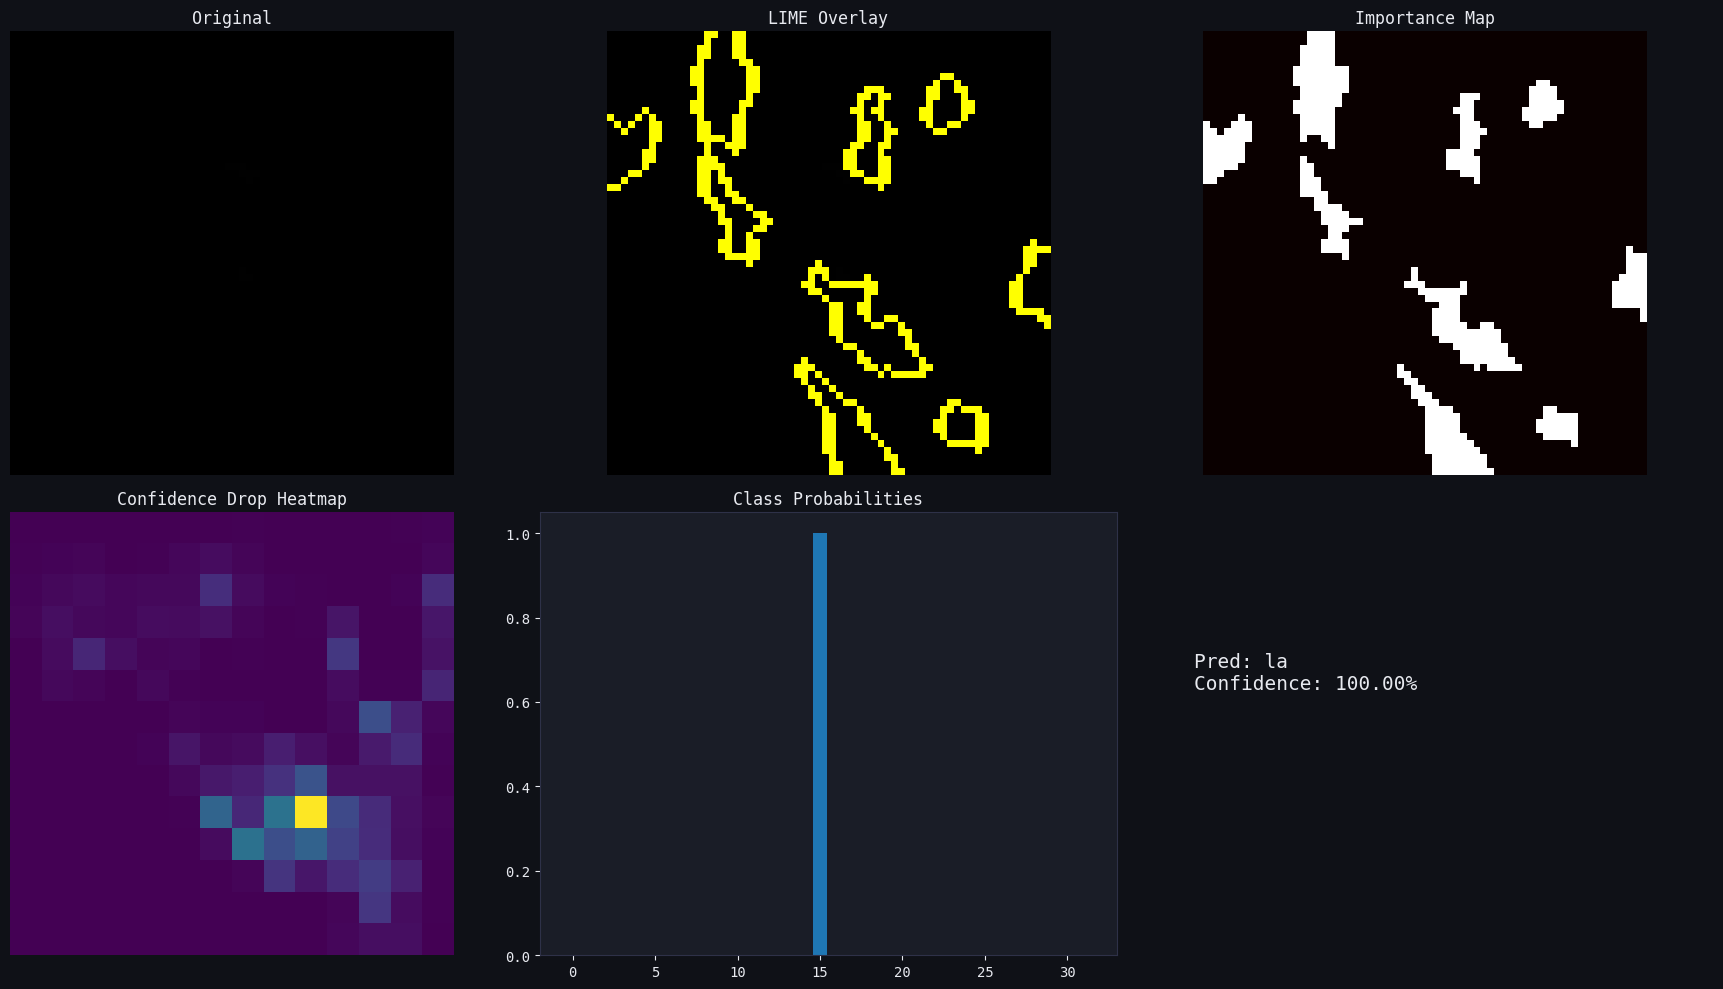

Saved: /kaggle/working/XAI_REPORT_1.png

SAMPLE 2/10
True : ta
Pred : dha
Conf : 52.01%


  0%|          | 0/1000 [00:00<?, ?it/s]

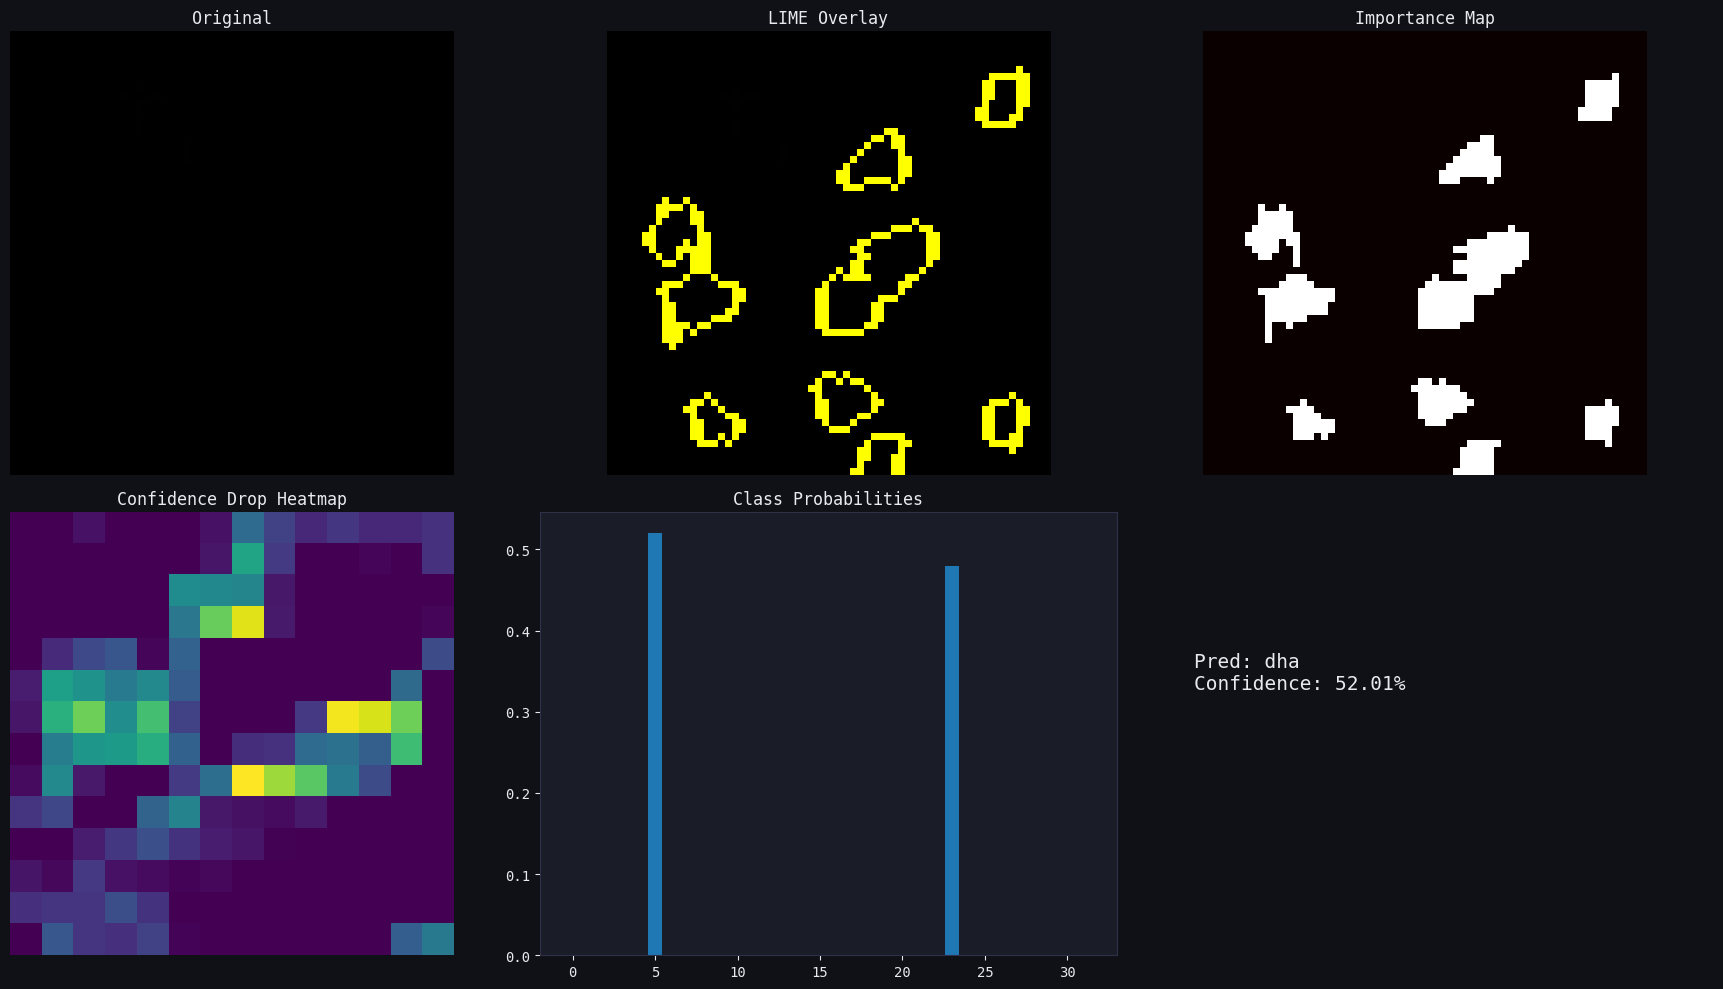

Saved: /kaggle/working/XAI_REPORT_2.png

SAMPLE 3/10
True : seen
Pred : seen
Conf : 100.00%


  0%|          | 0/1000 [00:00<?, ?it/s]

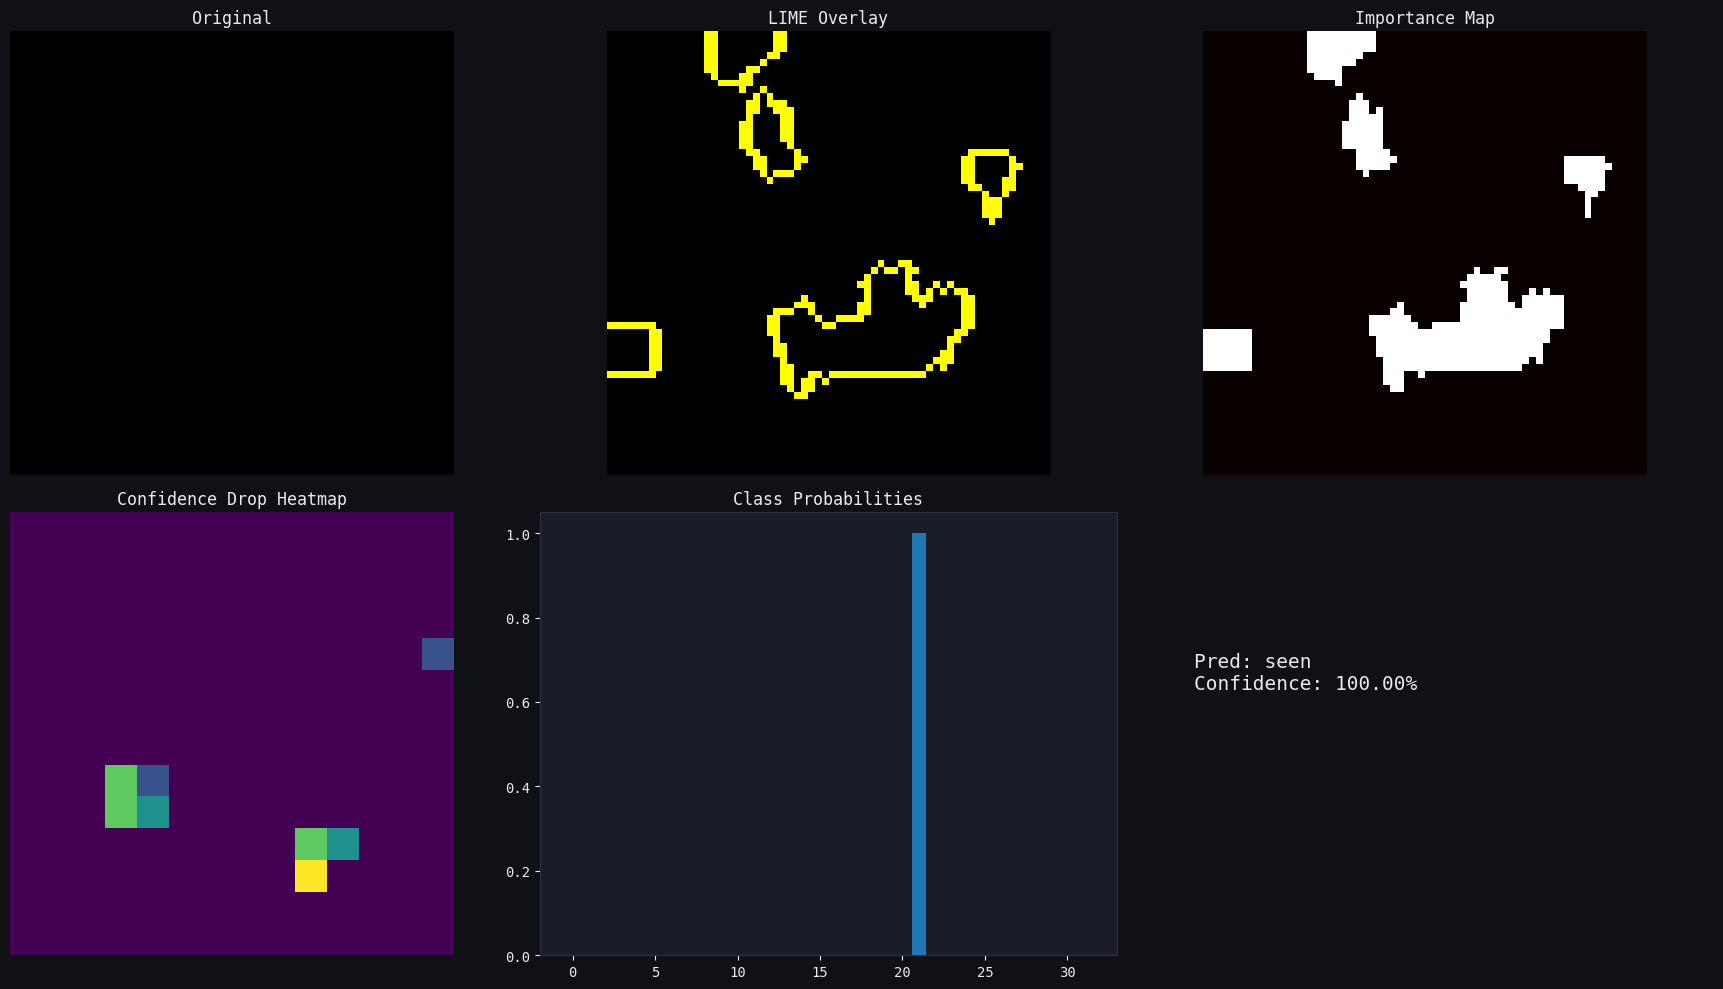

Saved: /kaggle/working/XAI_REPORT_3.png

SAMPLE 4/10
True : zay
Pred : zay
Conf : 100.00%


  0%|          | 0/1000 [00:00<?, ?it/s]

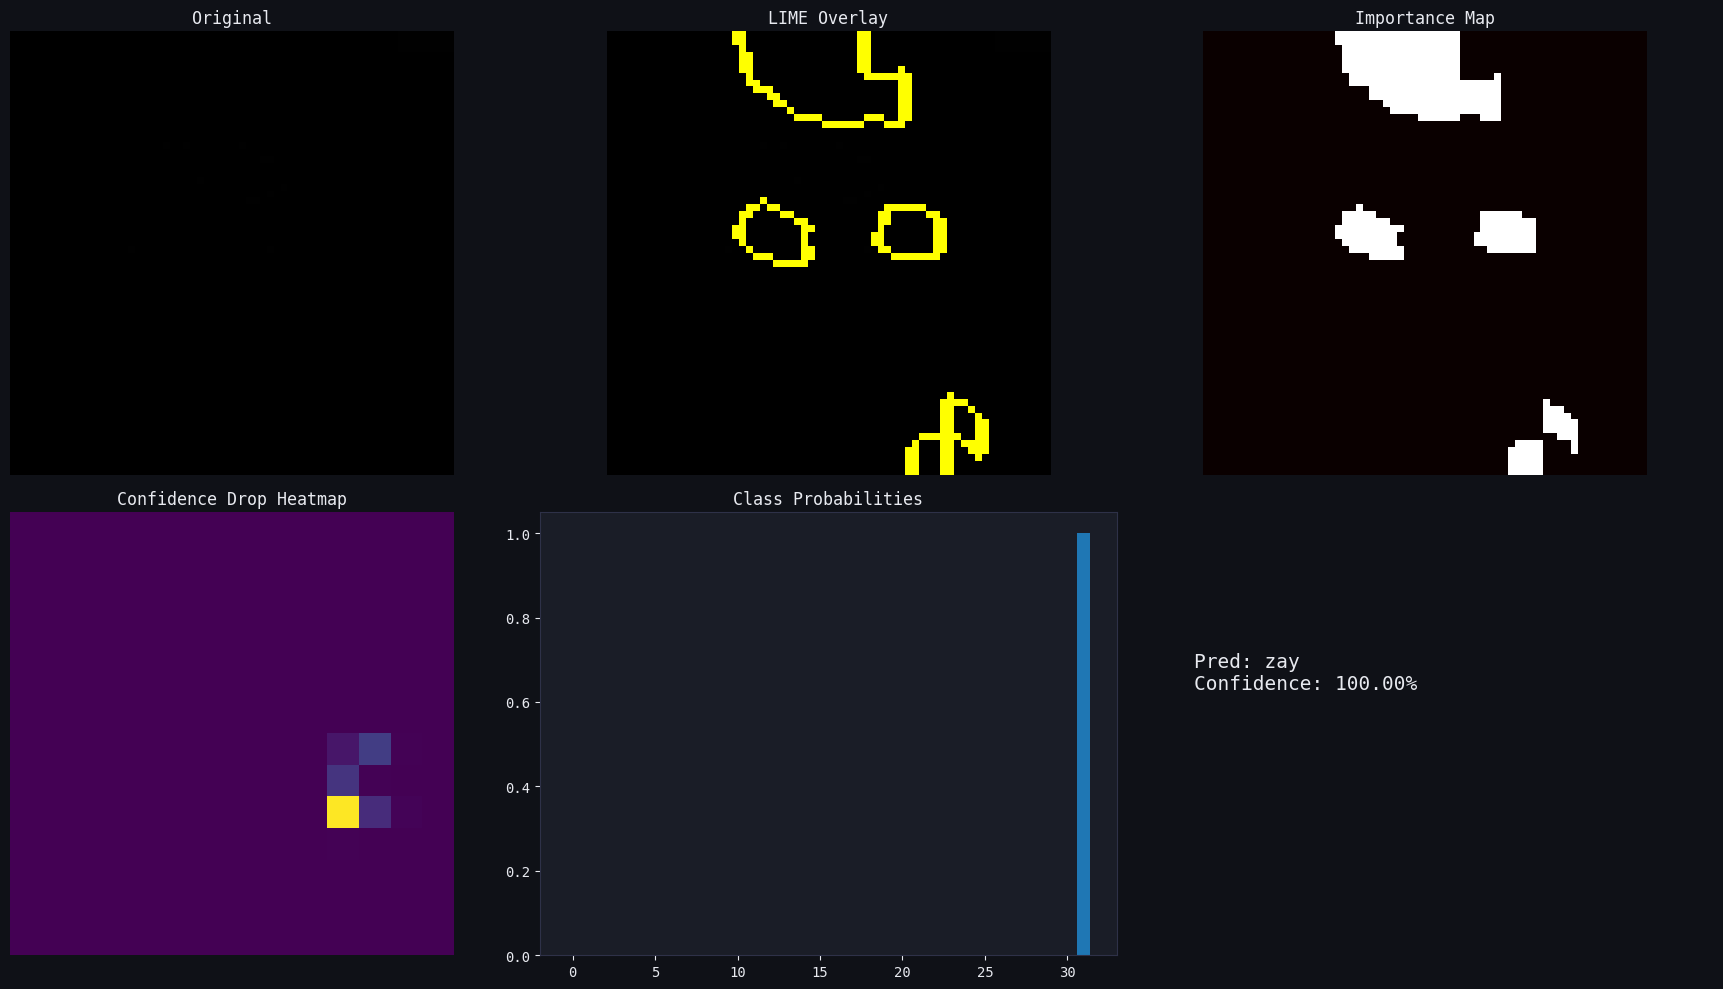

Saved: /kaggle/working/XAI_REPORT_4.png

SAMPLE 5/10
True : ha
Pred : ha
Conf : 100.00%


  0%|          | 0/1000 [00:00<?, ?it/s]

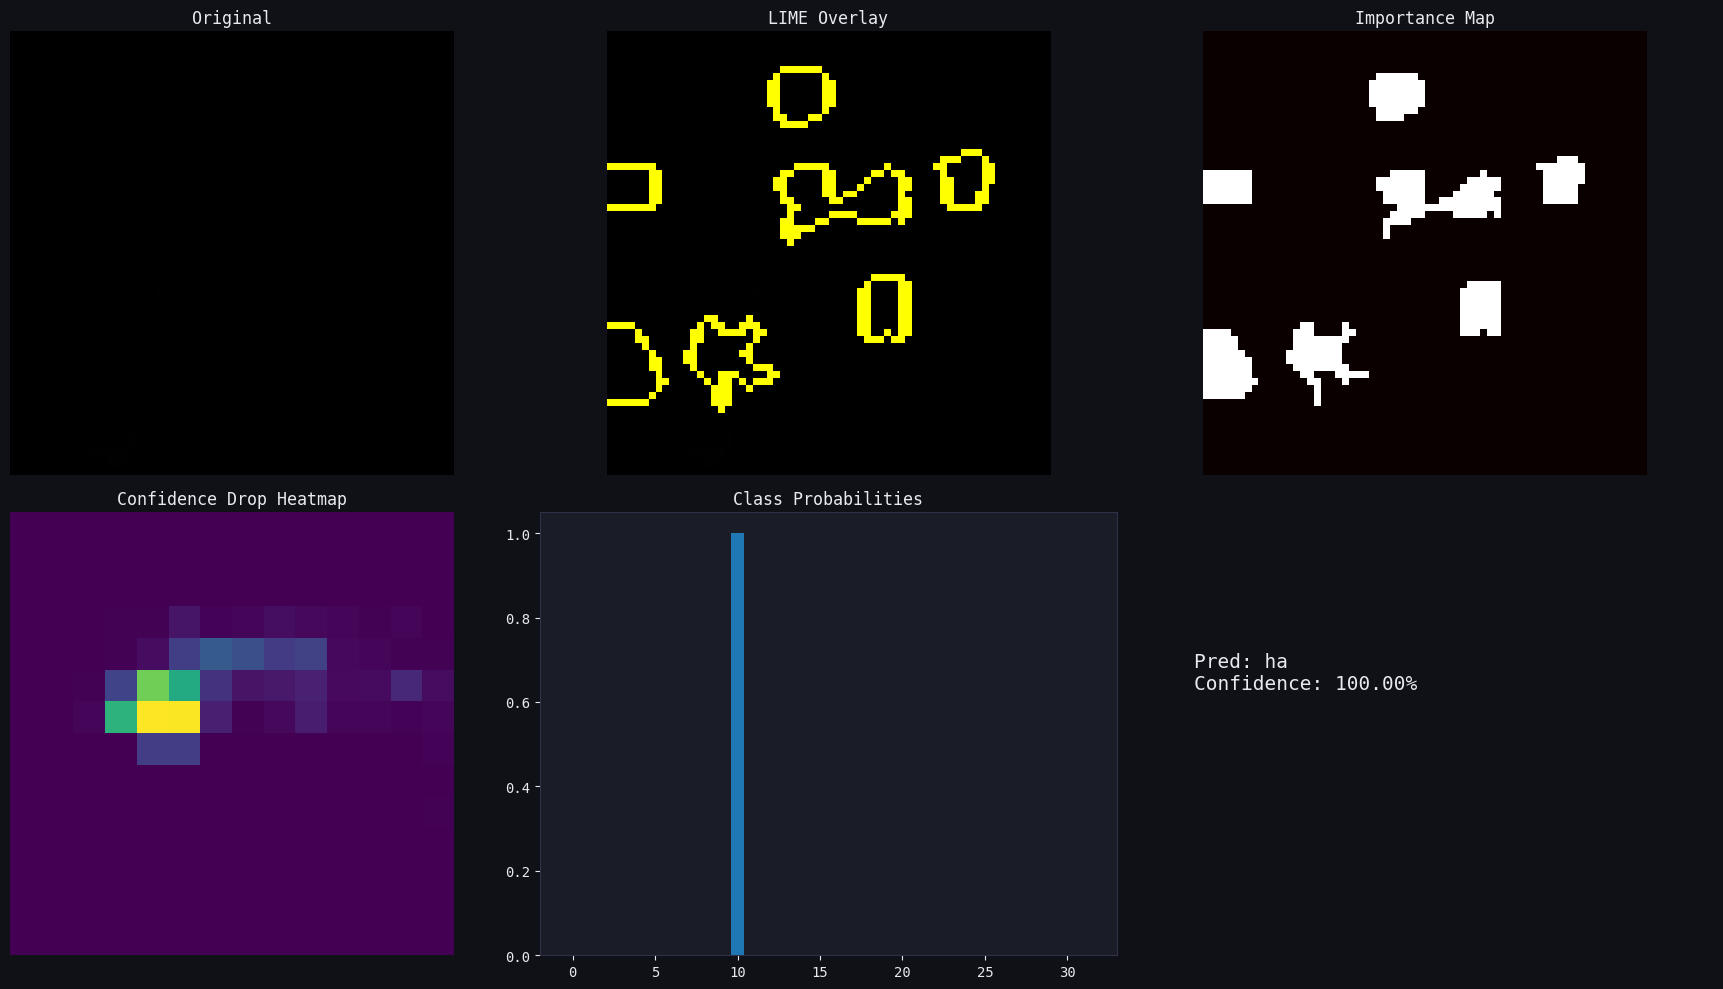

Saved: /kaggle/working/XAI_REPORT_5.png

SAMPLE 6/10
True : laam
Pred : laam
Conf : 100.00%


  0%|          | 0/1000 [00:00<?, ?it/s]

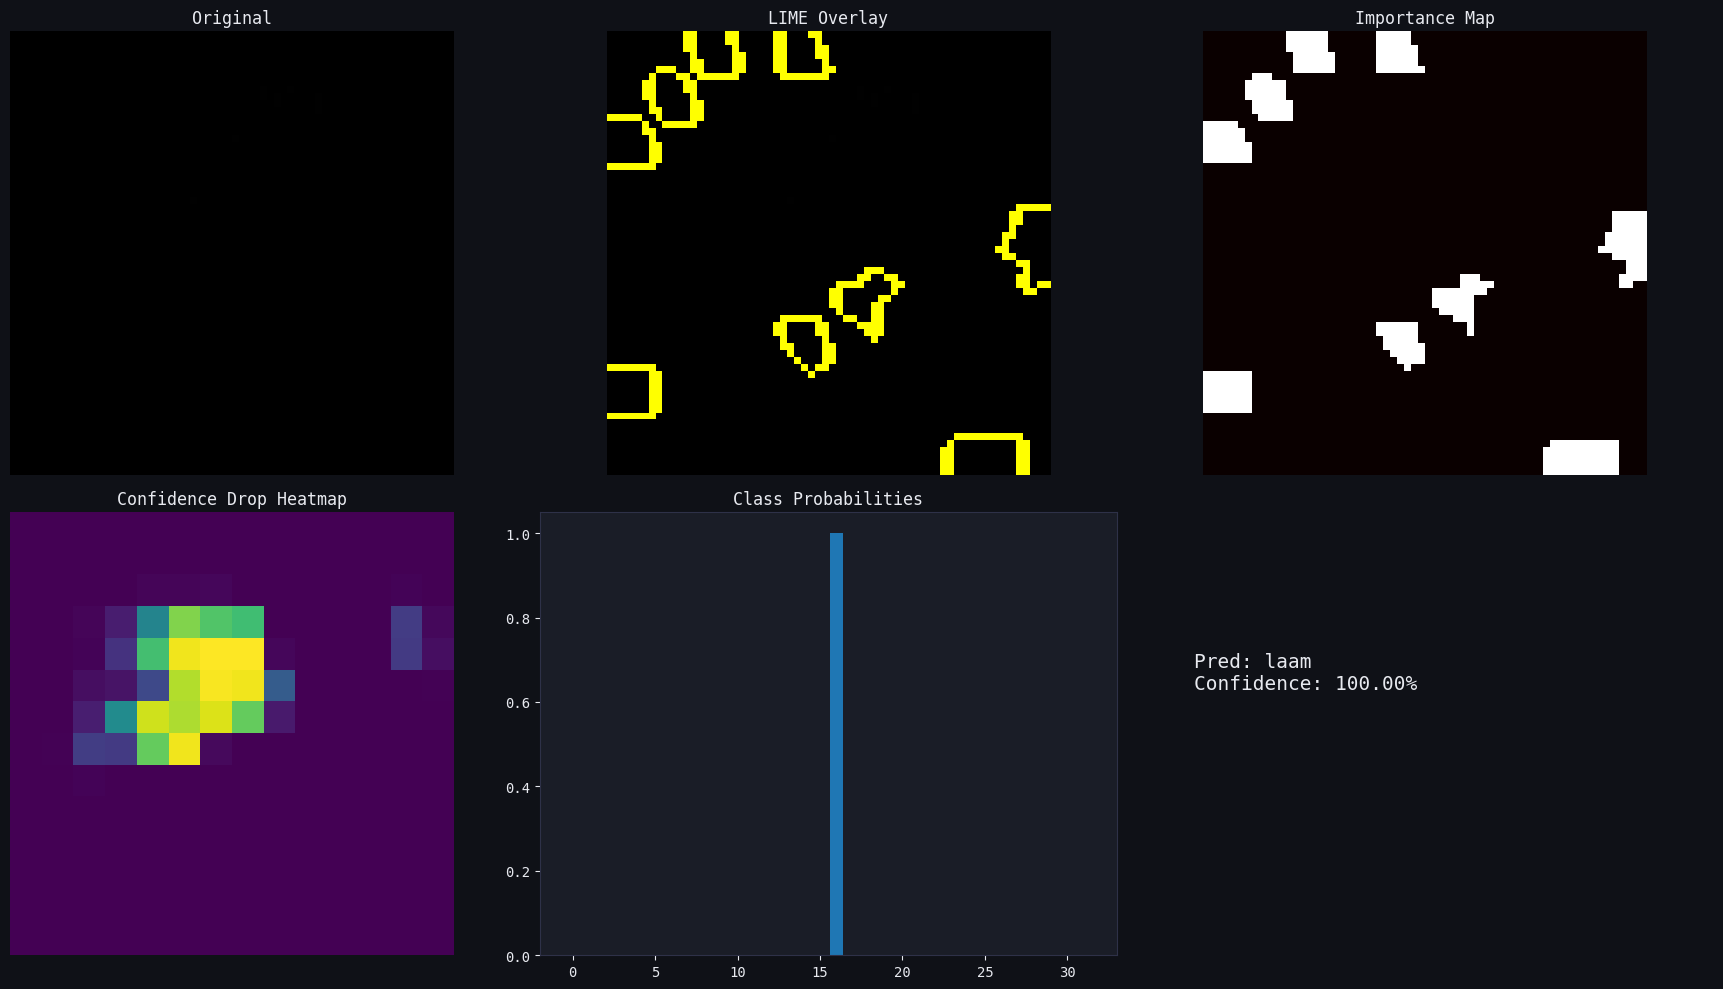

Saved: /kaggle/working/XAI_REPORT_6.png

SAMPLE 7/10
True : toot
Pred : toot
Conf : 100.00%


  0%|          | 0/1000 [00:00<?, ?it/s]

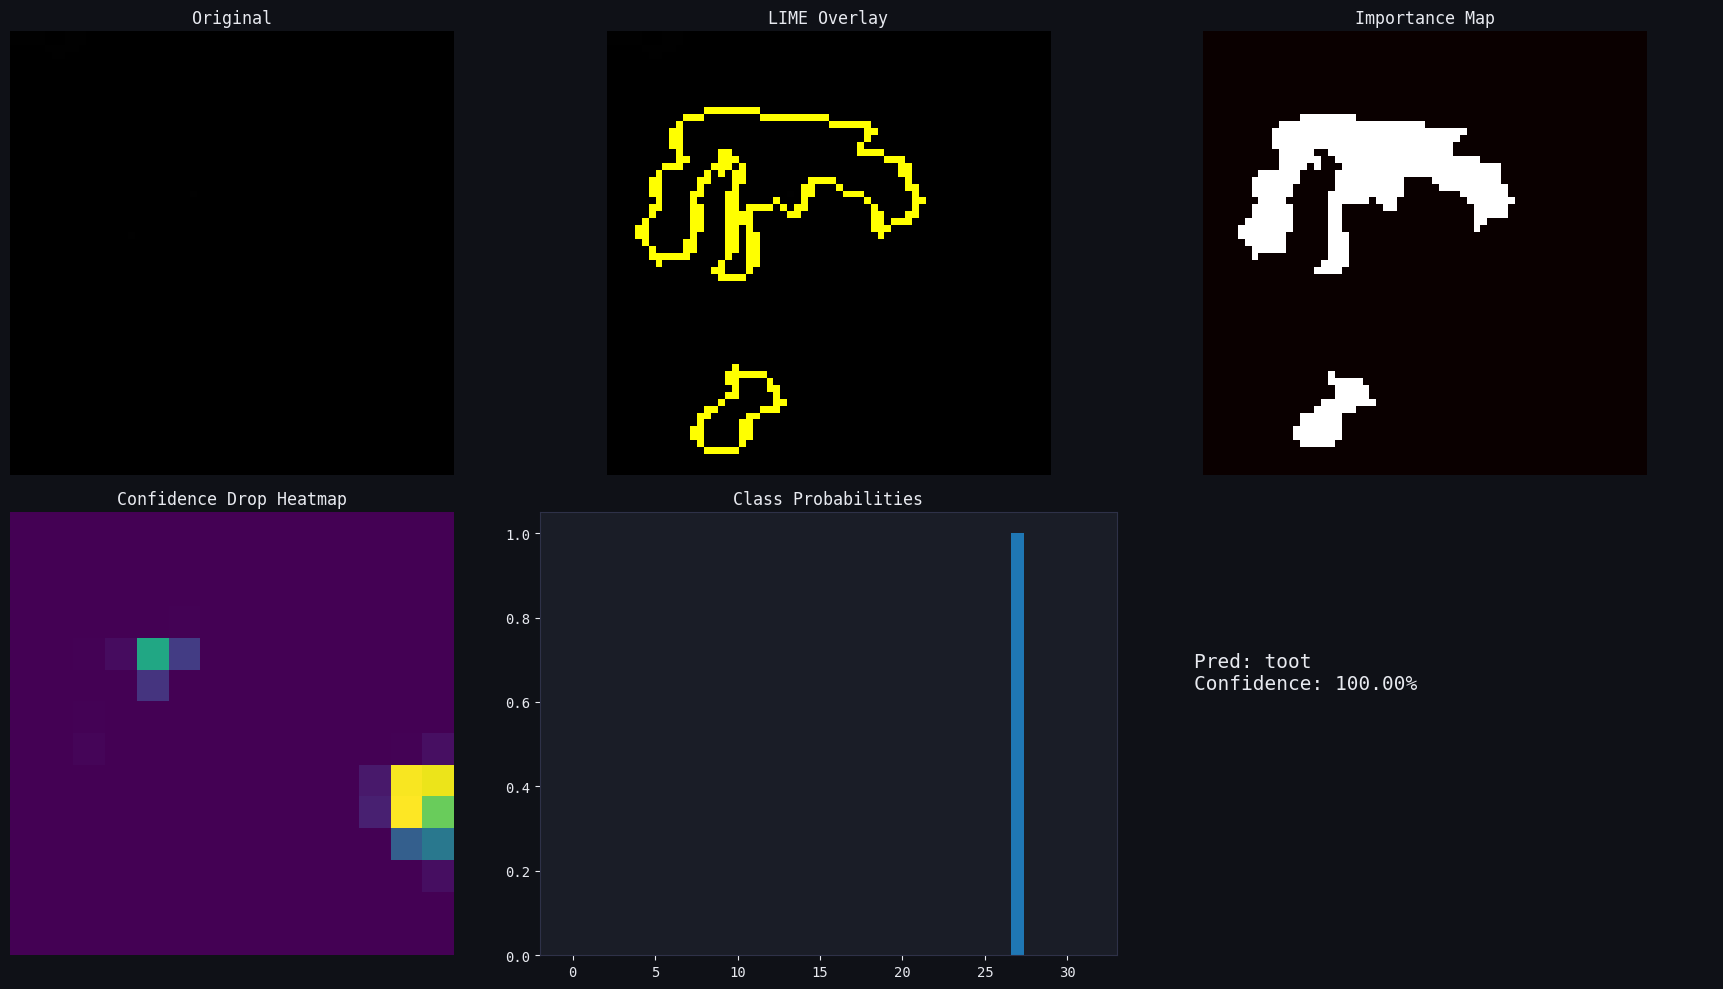

Saved: /kaggle/working/XAI_REPORT_7.png

SAMPLE 8/10
True : al
Pred : al
Conf : 100.00%


  0%|          | 0/1000 [00:00<?, ?it/s]

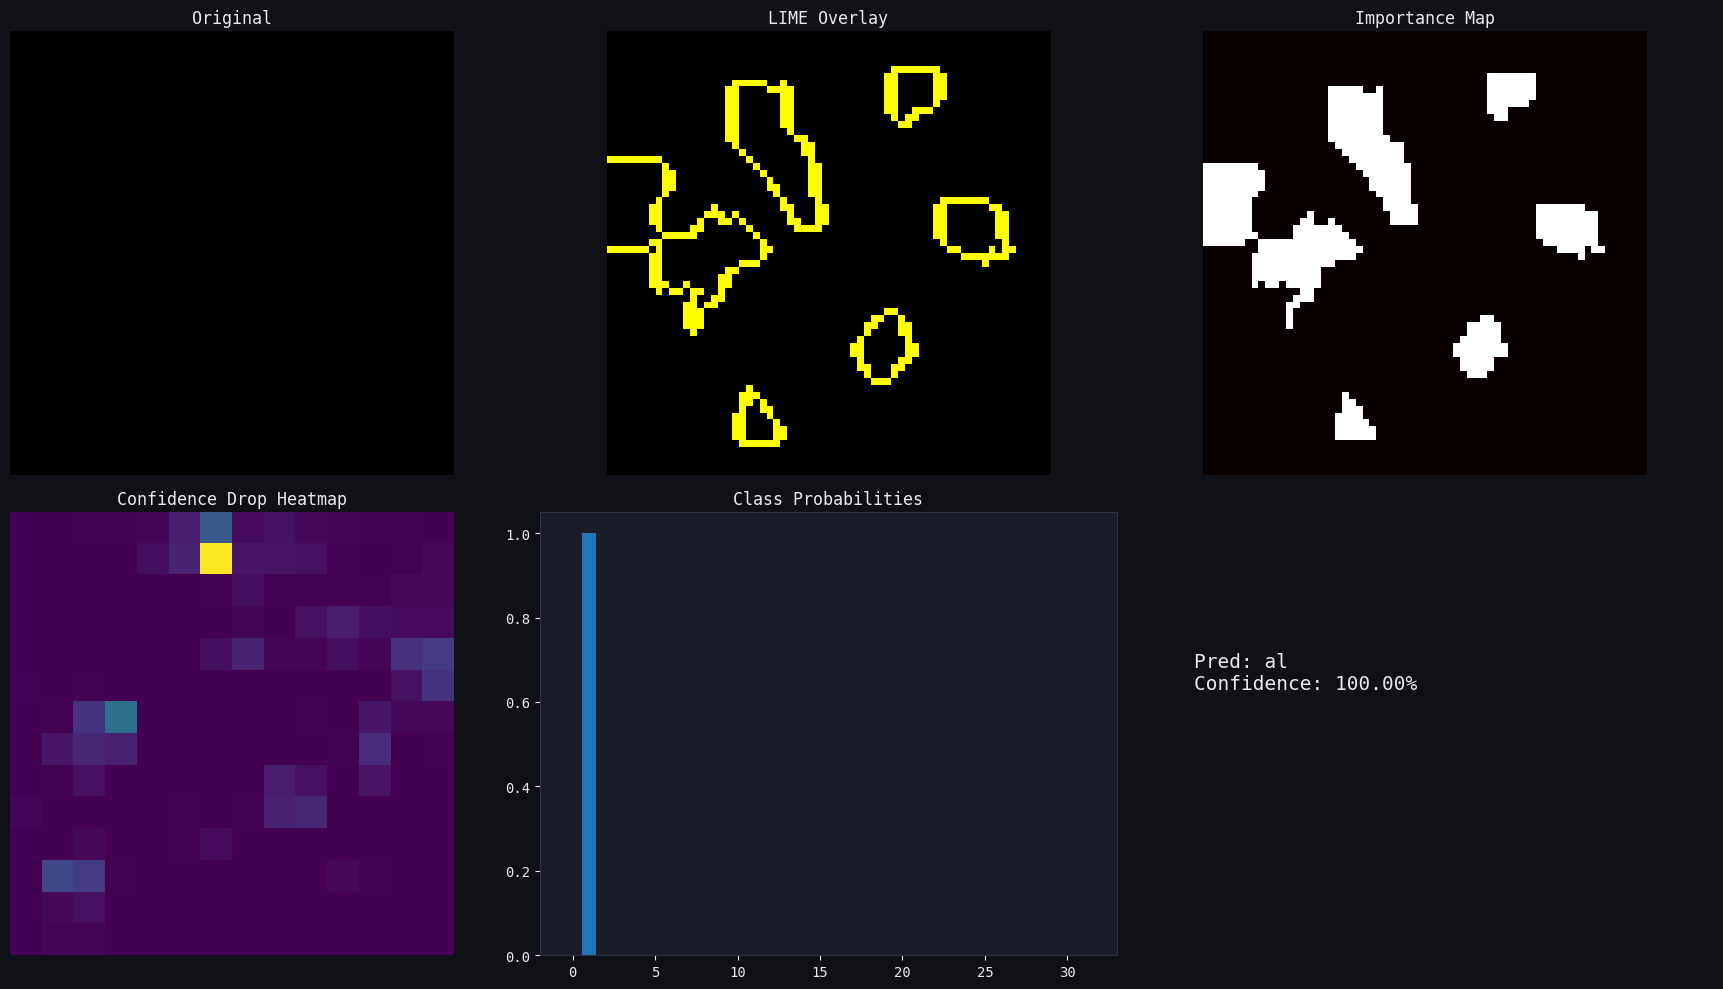

Saved: /kaggle/working/XAI_REPORT_8.png

SAMPLE 9/10
True : thal
Pred : thal
Conf : 99.96%


  0%|          | 0/1000 [00:00<?, ?it/s]

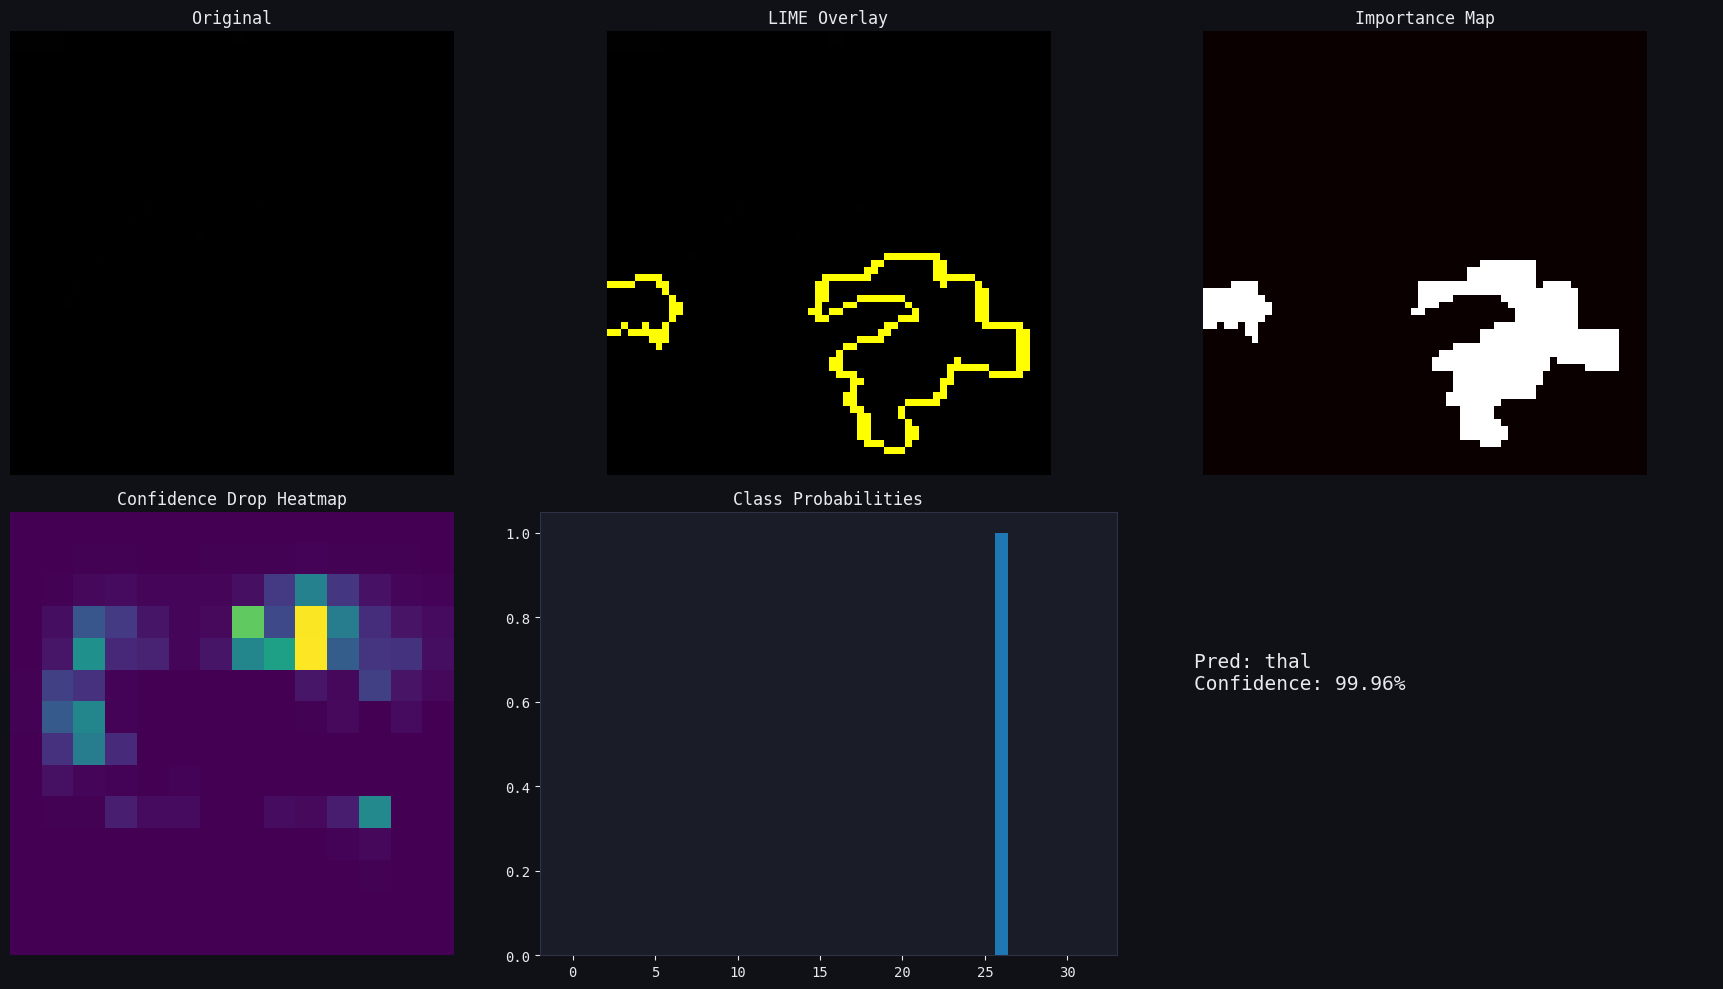

Saved: /kaggle/working/XAI_REPORT_9.png

SAMPLE 10/10
True : seen
Pred : seen
Conf : 100.00%


  0%|          | 0/1000 [00:00<?, ?it/s]

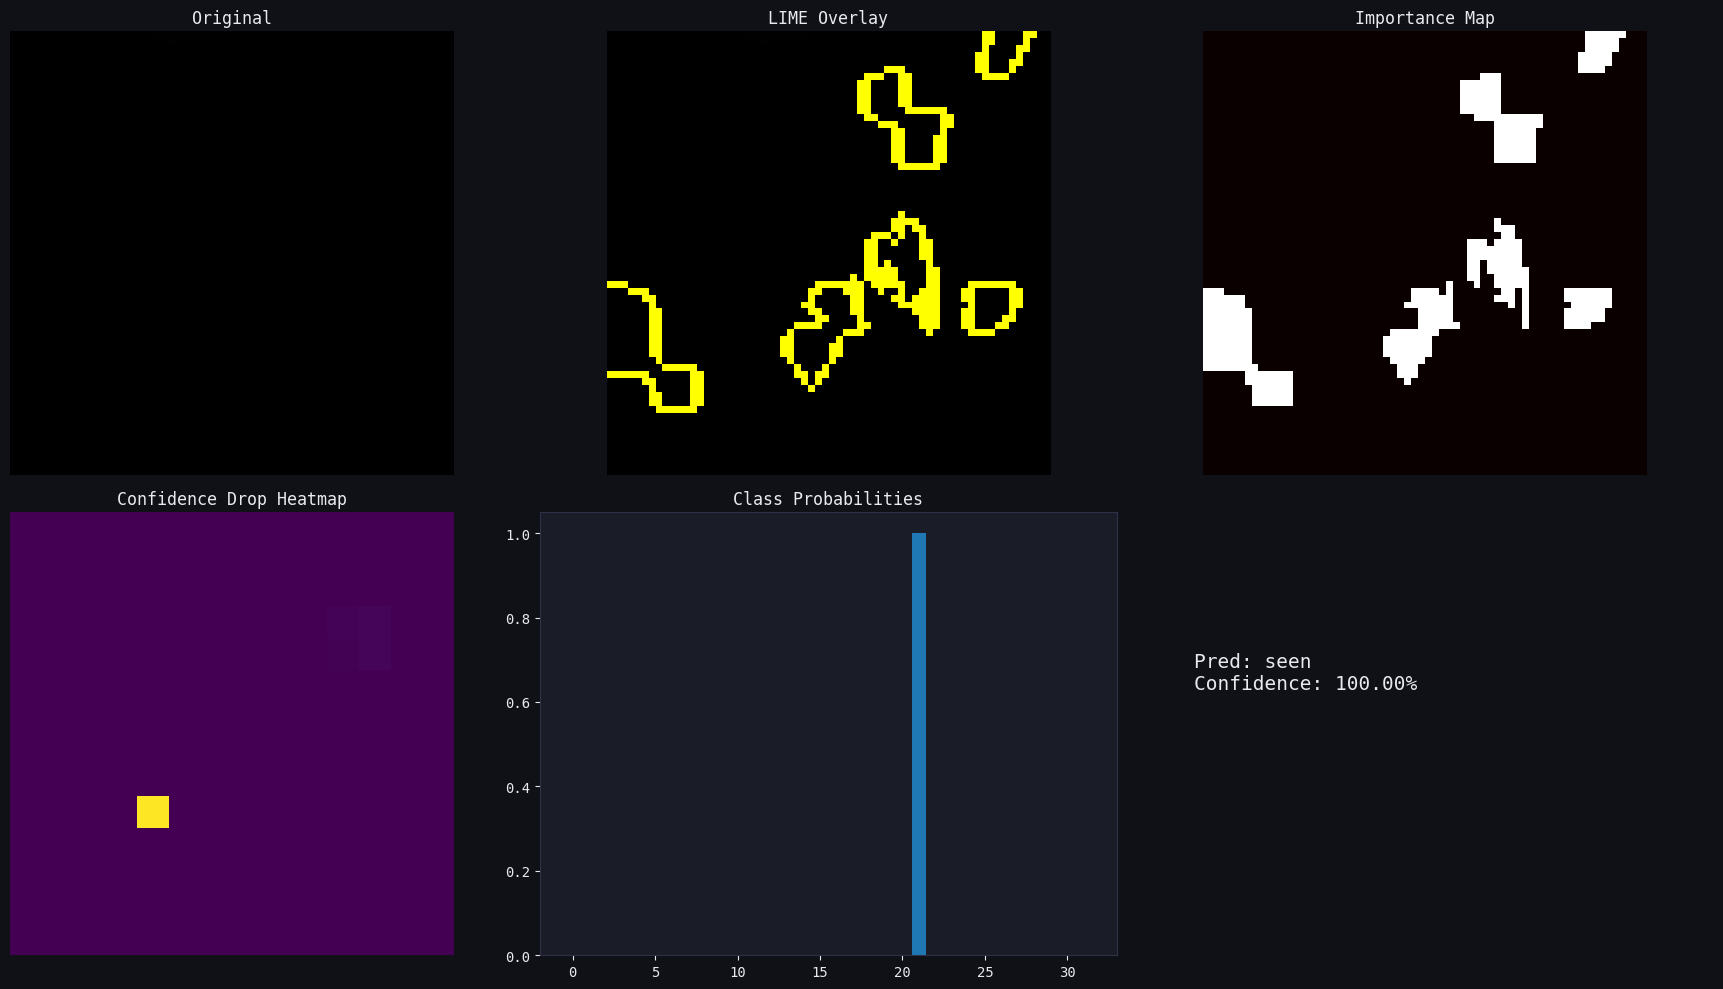

Saved: /kaggle/working/XAI_REPORT_10.png

DONE: 10 XAI REPORT IMAGES GENERATED


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPLETE LIME + QUANTITATIVE XAI (10 INDIVIDUAL REPORT IMAGES)
# ══════════════════════════════════════════════════════════════════════════════

!pip install lime -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import slic, mark_boundaries
from skimage.transform import resize
from scipy.ndimage import gaussian_filter
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

tf.keras.backend.clear_session()

# ══════════════════════════════════════════════════════════════════════════════
# MODEL INFO
# ══════════════════════════════════════════════════════════════════════════════

H, W, C = model.input_shape[1:]
print("Model Input Shape:", model.input_shape)

# ══════════════════════════════════════════════════════════════════════════════
# STYLE
# ══════════════════════════════════════════════════════════════════════════════

BG = "#0f1117"
CARD = "#1a1d27"
TEXT = "#e8eaf0"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": CARD,
    "axes.edgecolor": "#2e3148",
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "font.family": "monospace",
})

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def to_rgb(image):
    im = np.asarray(image).astype("float32")

    if im.ndim == 2:
        im = np.repeat(im[..., None], 3, axis=-1)
    elif im.shape[-1] == 1:
        im = np.repeat(im, 3, axis=-1)

    im = im[..., :3]

    if im.max() > 1:
        im /= 255.0

    return np.clip(im, 0, 1)


def preprocess_batch(images):
    out = []

    for im in images:
        im = np.asarray(im).astype("float32")

        if C == 1:
            if im.ndim == 3:
                im = np.mean(im, axis=-1, keepdims=True)
            im = resize(im, (H, W, 1), preserve_range=True)
        else:
            if im.ndim == 2:
                im = np.repeat(im[..., None], 3, axis=-1)
            im = im[..., :3]
            im = resize(im, (H, W, 3), preserve_range=True)

        if im.max() > 1:
            im /= 255.0

        out.append(im.astype("float32"))

    return np.array(out)


def predict_fn(images):
    return model.predict(preprocess_batch(images), verbose=0)


def get_conf(img, cls):
    return model.predict(preprocess_batch([img]), verbose=0)[0][cls]


def blur(img):
    return gaussian_filter(img, sigma=10)


# ══════════════════════════════════════════════════════════════════════════════
# CONFIDENCE HEATMAP
# ══════════════════════════════════════════════════════════════════════════════

def confidence_heatmap(image, cls, grid=14):
    h, w = image.shape[:2]
    heat = np.zeros((grid, grid))

    bh, bw = h // grid, w // grid
    base = get_conf(image, cls)

    for i in range(grid):
        for j in range(grid):

            temp = image.copy()
            temp[i*bh:(i+1)*bh, j*bw:(j+1)*bw] = 0

            heat[i, j] = base - get_conf(temp, cls)

    return np.maximum(heat, 0)


# ══════════════════════════════════════════════════════════════════════════════
# LIME
# ══════════════════════════════════════════════════════════════════════════════

explainer = lime_image.LimeImageExplainer(random_state=42)

# ══════════════════════════════════════════════════════════════════════════════
# SAMPLE SELECTION
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(42)

n_explain = 10
indices = np.random.choice(len(x_val), n_explain, replace=False)

# ══════════════════════════════════════════════════════════════════════════════
# MAIN LOOP
# ══════════════════════════════════════════════════════════════════════════════

for i, idx in enumerate(indices, 1):

    print("\n" + "="*70)
    print(f"SAMPLE {i}/{n_explain}")
    print("="*70)

    image = x_val[idx]
    image_rgb = to_rgb(image)
    true_label = int(y_val[idx])

    preds = model.predict(preprocess_batch([image]), verbose=0)[0]
    pred_label = np.argmax(preds)
    conf = preds[pred_label]

    print("True :", class_names[true_label])
    print("Pred :", class_names[pred_label])
    print("Conf :", f"{conf:.2%}")

    # ═════════ LIME ═════════
    explanation = explainer.explain_instance(
        image_rgb.astype("double"),
        classifier_fn=predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000,
        segmentation_fn=lambda x: slic(x, n_segments=100, compactness=10)
    )

    lime_img, lime_mask = explanation.get_image_and_mask(
        label=pred_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    importance_mask = (lime_mask > 0).astype(np.uint8)

    # ═════════ HEATMAP ═════════
    conf_map = confidence_heatmap(image_rgb, pred_label)

    # ═════════ PLOT ═════════
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.patch.set_facecolor(BG)

    # Original
    axes[0, 0].imshow(image_rgb)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")

    # LIME overlay
    overlay = mark_boundaries(lime_img, lime_mask)
    axes[0, 1].imshow(overlay)
    axes[0, 1].set_title("LIME Overlay")
    axes[0, 1].axis("off")

    # Importance
    axes[0, 2].imshow(lime_mask, cmap="hot")
    axes[0, 2].set_title("Importance Map")
    axes[0, 2].axis("off")

    # Confidence heatmap
    axes[1, 0].imshow(conf_map, cmap="viridis")
    axes[1, 0].set_title("Confidence Drop Heatmap")
    axes[1, 0].axis("off")

    # Probabilities
    axes[1, 1].bar(range(len(preds)), preds)
    axes[1, 1].set_title("Class Probabilities")

    # Text summary
    axes[1, 2].text(
        0.1, 0.6,
        f"Pred: {class_names[pred_label]}\nConfidence: {conf:.2%}",
        fontsize=14
    )
    axes[1, 2].axis("off")

    plt.tight_layout()

    # ═════════ SAVE ═════════
    path = f"/kaggle/working/XAI_REPORT_{i}.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()

    print("Saved:", path)

print("\nDONE: 10 XAI REPORT IMAGES GENERATED")

In [10]:
import tensorflow as tf
from tensorflow.python.framework import convert_to_constants

# ─────────────────────────────────────────────
# 1) نجيب input shape من الموديل
# ─────────────────────────────────────────────
input_shape = model.input_shape

# لو فيه batch None نخليه 1
input_shape = tuple([1 if x is None else x for x in input_shape])

print("  📐 Used input shape for FLOPs:", input_shape)


# ─────────────────────────────────────────────
# 2) FLOPs function
# ─────────────────────────────────────────────
def get_flops(model, input_shape):

    full_model = tf.function(lambda x: model(x))
    full_model = full_model.get_concrete_function(
        tf.TensorSpec(input_shape, tf.float32)
    )

    frozen_func = convert_to_constants.convert_variables_to_constants_v2(full_model)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.import_graph_def(graph_def, name="")

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd="op",
            options=opts
        )

        return flops.total_float_ops


# ─────────────────────────────────────────────
# 3) الحساب
# ─────────────────────────────────────────────
flops = get_flops(model, input_shape)

flops_m = flops / 1e6
macs_m  = flops_m / 2   # approximation

# ─────────────────────────────────────────────
# 4) output
# ─────────────────────────────────────────────
print("\n==============================")
print("  ⚡ Model Complexity")
print("==============================")
print(f"FLOPs  : {flops_m:.4f} M")
print(f"MACs   : {macs_m:.4f} M")

  📐 Used input shape for FLOPs: (1, 64, 64, 1)


I0000 00:00:1779353626.997893      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1779353626.998089      57 single_machine.cc:374] Starting new session
I0000 00:00:1779353626.999070      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th